<a href="https://colab.research.google.com/github/AvniSriram/Sex-Specific-AD-Microglia/blob/main/code/Morpho_Test5_3_corr_heatmap_update.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install neurom

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.6/536.6 kB 35.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 5.1 MB/s eta 0:00:00
  Created wheel for neurom: filename=neurom-4.0.5-py3-none-any.whl size=110130 sha256=615c4a18399de1bb1716eac7f92a50940fb8a0b24f2a0290f8b18cdcbfdaebbf
  Stored in directory: /root/.cache/pip/wheels/14/2c/59/1af8bbdd92bc14980684dcba369e060a97a2f82ba9b7ca0cc0
Successfully built neurom


In [ ]:
print("Hello world")

In [ ]:
import neurom as nm
from neurom.view import plot_morph, plot_morph3d, plot_dendrogram
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [ ]:
import zipfile
import os

zip_path = '/content/ASSIP_Full_Control_Metadata.zip'
extract_to = '/content/ASSIP_Full_Control_Metadata'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipping complete!")

Unzipping complete!


In [ ]:
zip_path = '/content/ASSIP_Full_Control_SWC.zip'
extract_to = '/content/ASSIP_Full_Control_SWC'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipping complete!")

Unzipping complete!


In [ ]:
zip_path = '/content/ASSIP_Full_AD_SWC.zip'
extract_to = '/content/ASSIP_Full_AD_SWC'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipping complete!")

Unzipping complete!


In [ ]:
zip_path = '/content/ASSIP_Full_AD_Metadata.zip'
extract_to = '/content/ASSIP_Full_AD_Metadata'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipping complete!")

Unzipping complete!


In [ ]:
AD_PATH = '/content/ASSIP_Full_AD_SWC/ASSIP_Full_AD_SWC'
CONTROL_PATH = '/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC'

ad_files = [os.path.join(AD_PATH, f)
            for f in os.listdir(AD_PATH)
            if f.lower().endswith('.swc')]

control_files = [os.path.join(CONTROL_PATH, f)
                 for f in os.listdir(CONTROL_PATH)
                 if f.lower().endswith('.swc')]

print('AD files:', len(ad_files))
print('Control files:', len(control_files))

AD files: 1176
Control files: 4859


In [ ]:
all_files = [(f, 'AD') for f in ad_files] + [(f, 'Control') for f in control_files]

In [ ]:
from neurom.core.soma import SomaError

data = []
skipped_count = 0

for filepath, label in all_files:
    try:
        m = nm.load_morphology(filepath)
    except (AssertionError, SomaError) as e:
        print(f"Skipping {os.path.basename(filepath)} due to error: {e}")
        skipped_count += 1
        continue
    local_bif_angles = []
    for s in nm.iter_sections(m):
        if len(s.children) == 2:
            angle = nm.features.bifurcation.local_bifurcation_angle(s)
            local_bif_angles.append(angle)

    mean_local_bif_angle = np.mean(local_bif_angles) if local_bif_angles else 0

    soma_vol = nm.features.morphology.soma_volume(m)
    soma_area = nm.features.morphology.soma_surface_area(m)
    soma_rad = nm.features.morphology.soma_radius(m)

    num_neurites = nm.get('number_of_neurites', m)
    num_sections = nm.get('number_of_sections', m)
    num_segments = nm.get('number_of_segments', m)

    sec_lengths = nm.get('section_lengths', m)
    seg_lengths = nm.get('segment_lengths', m)

    mean_sec_len = np.mean(sec_lengths) if sec_lengths else 0
    mean_seg_len = np.mean(seg_lengths) if seg_lengths else 0

    n_bifs = sum(1 for s in nm.iter_sections(m) if len(s.children) == 2)

    data.append({
        'neuron_name': os.path.basename(filepath),
        'group': label,
        'soma_volume': soma_vol if soma_vol is not None else np.nan,
        'soma_surface_area': soma_area if soma_area is not None else np.nan,
        'soma_radius': soma_rad if soma_rad is not None else np.nan,
        'number_of_neurites': num_neurites if num_neurites is not None else np.nan,
        'number_of_sections': num_sections if num_sections is not None else np.nan,
        'number_of_segments': num_segments if num_segments is not None else np.nan,
        'mean_section_length': mean_sec_len if mean_sec_len is not None else np.nan,
        'mean_segment_length': mean_seg_len if mean_seg_len is not None else np.nan,
        'mean_local_bif_angle': mean_local_bif_angle if mean_local_bif_angle is not None else np.nan,
        'n_bifs': n_bifs if n_bifs is not None else np.nan
    })

/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:352: UserWarning: Approximating soma volume by a sphere. <morphio._morphio.Soma object at 0x780176b97470>
  warnings.warn('Approximating soma volume by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:310: UserWarning: Approximating soma area by a sphere. <morphio._morphio.Soma object at 0x780176b97470>
  warnings.warn('Approximating soma area by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:352: UserWarning: Approximating soma volume by a sphere. <morphio._morphio.Soma object at 0x780176bc3a70>
  warnings.warn('Approximating soma volume by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:310: UserWarning: Approximating soma area by a sphere. <morphio._morphio.Soma object at 0x780176bc3a70>
  warnings.warn('Approximating soma area by a sphere. {}'.format(morphio_soma))
/usr/local/lib/p

Skipping 3DDS_14_VK.CNG.swc due to error: 
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/3DDS_14_VK.CNG.swc:14:error

Found soma bifurcation
The following children have been found:
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/3DDS_14_VK.CNG.swc:15:warning


/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/3DDS_14_VK.CNG.swc:42:warning




/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:352: UserWarning: Approximating soma volume by a sphere. <morphio._morphio.Soma object at 0x780176c12e30>
  warnings.warn('Approximating soma volume by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:310: UserWarning: Approximating soma area by a sphere. <morphio._morphio.Soma object at 0x780176c12e30>
  warnings.warn('Approximating soma area by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:352: UserWarning: Approximating soma volume by a sphere. <morphio._morphio.Soma object at 0x780176c3fbf0>
  warnings.warn('Approximating soma volume by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:310: UserWarning: Approximating soma area by a sphere. <morphio._morphio.Soma object at 0x780176c3fbf0>
  warnings.warn('Approximating soma area by a sphere. {}'.format(morphio_soma))
/usr/local/lib/p

Skipping 3DDS_6_VK.CNG.swc due to error: 
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/3DDS_6_VK.CNG.swc:3:error

Found soma bifurcation
The following children have been found:
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/3DDS_6_VK.CNG.swc:4:warning


/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/3DDS_6_VK.CNG.swc:93:warning




/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:352: UserWarning: Approximating soma volume by a sphere. <morphio._morphio.Soma object at 0x780176c3f7f0>
  warnings.warn('Approximating soma volume by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:310: UserWarning: Approximating soma area by a sphere. <morphio._morphio.Soma object at 0x780176c3f7f0>
  warnings.warn('Approximating soma area by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:352: UserWarning: Approximating soma volume by a sphere. <morphio._morphio.Soma object at 0x780176c3f230>
  warnings.warn('Approximating soma volume by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:310: UserWarning: Approximating soma area by a sphere. <morphio._morphio.Soma object at 0x780176c3f230>
  warnings.warn('Approximating soma area by a sphere. {}'.format(morphio_soma))
/usr/local/lib/p

...

/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:352: UserWarning: Approximating soma volume by a sphere. <morphio._morphio.Soma object at 0x7801764e72f0>
  warnings.warn('Approximating soma volume by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:310: UserWarning: Approximating soma area by a sphere. <morphio._morphio.Soma object at 0x7801764e72f0>
  warnings.warn('Approximating soma area by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:352: UserWarning: Approximating soma volume by a sphere. <morphio._morphio.Soma object at 0x7801764e7370>
  warnings.warn('Approximating soma volume by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:310: UserWarning: Approximating soma area by a sphere. <morphio._morphio.Soma object at 0x7801764e7370>
  warnings.warn('Approximating soma area by a sphere. {}'.format(morphio_soma))
/usr/local/lib/p

Skipping 3DDS_15_VK.CNG.swc due to error: 
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/3DDS_15_VK.CNG.swc:3:error

Found soma bifurcation
The following children have been found:
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/3DDS_15_VK.CNG.swc:4:warning


/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/3DDS_15_VK.CNG.swc:6:warning




/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:352: UserWarning: Approximating soma volume by a sphere. <morphio._morphio.Soma object at 0x7801764e6e70>
  warnings.warn('Approximating soma volume by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:310: UserWarning: Approximating soma area by a sphere. <morphio._morphio.Soma object at 0x7801764e6e70>
  warnings.warn('Approximating soma area by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:352: UserWarning: Approximating soma volume by a sphere. <morphio._morphio.Soma object at 0x7801764e7b30>
  warnings.warn('Approximating soma volume by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:310: UserWarning: Approximating soma area by a sphere. <morphio._morphio.Soma object at 0x7801764e7b30>
  warnings.warn('Approximating soma area by a sphere. {}'.format(morphio_soma))


Skipping Kyrargyri_Attwell_C2-4.CNG.swc due to error: 
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/Kyrargyri_Attwell_C2-4.CNG.swc:531:error

Found soma bifurcation
The following children have been found:
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/Kyrargyri_Attwell_C2-4.CNG.swc:532:warning


/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/Kyrargyri_Attwell_C2-4.CNG.swc:549:warning


Skipping 3DDS_20_VK.CNG.swc due to error: 
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/3DDS_20_VK.CNG.swc:363:error

Found soma bifurcation
The following children have been found:
/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/3DDS_20_VK.CNG.swc:364:warning


/content/ASSIP_Full_Control_SWC/ASSIP_Full_Control_SWC/3DDS_20_VK.CNG.swc:724:warning




/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:352: UserWarning: Approximating soma volume by a sphere. <morphio._morphio.Soma object at 0x7801764e71b0>
  warnings.warn('Approximating soma volume by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:310: UserWarning: Approximating soma area by a sphere. <morphio._morphio.Soma object at 0x7801764e71b0>
  warnings.warn('Approximating soma area by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:352: UserWarning: Approximating soma volume by a sphere. <morphio._morphio.Soma object at 0x7801764e78f0>
  warnings.warn('Approximating soma volume by a sphere. {}'.format(morphio_soma))
/usr/local/lib/python3.12/dist-packages/neurom/core/soma.py:310: UserWarning: Approximating soma area by a sphere. <morphio._morphio.Soma object at 0x7801764e78f0>
  warnings.warn('Approximating soma area by a sphere. {}'.format(morphio_soma))
/usr/local/lib/p

In [ ]:
from collections import Counter

skipped_files = []

for filepath, label in all_files:
    try:
        m = nm.load_morphology(filepath)
    except (AssertionError, SomaError) as e:
        skipped_files.append((os.path.basename(filepath), label))

print(f"Total skipped files: {len(skipped_files)}")

for fname, group in skipped_files:
    print(f"Skipped file: {fname}, Group: {group}")

group_counts = Counter(label for _, label in skipped_files)
print("Skipped files by group:")
for group, count in group_counts.items():
    print(f"{group}: {count}")


Total skipped files: 25
Skipped file: 3DDS_14_VK.CNG.swc, Group: Control
Skipped file: 3DDS_6_VK.CNG.swc, Group: Control
Skipped file: 3DDS_29_VK.CNG.swc, Group: Control
Skipped file: 3DDS_33_VK.CNG.swc, Group: Control
Skipped file: Kyrargyri_Attwell_C2-11.CNG.swc, Group: Control
Skipped file: 3DDS_27_VK.CNG.swc, Group: Control
Skipped file: 3DDS_25_VK.CNG.swc, Group: Control
Skipped file: Kyrargyri_Attwell_C2-28.CNG.swc, Group: Control
Skipped file: 3DDS_24_VK.CNG.swc, Group: Control
Skipped file: 3DDS_28_VK.CNG.swc, Group: Control
Skipped file: Kyrargyri_Attwell_C2-13.CNG.swc, Group: Control
Skipped file: 3DDS_22_VK.CNG.swc, Group: Control
Skipped file: 3DDS_31_VK.CNG.swc, Group: Control
Skipped file: Kyrargyri_Attwell_C2-12.CNG.swc, Group: Control
Skipped file: 3DDS_13_VK.CNG.swc, Group: Control
Skipped file: Kyrargyri_Attwell_C2-7.CNG.swc, Group: Control
Skipped file: Kyrargyri_Attwell_C2-3.CNG.swc, Group: Control
Skipped file: Kyrargyri_Attwell_C2-10.CNG.swc, Group: Control
Skippe

In [ ]:
df = pd.DataFrame(data)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.DataFrame(data)

df.to_excel('/content/drive/MyDrive/ASSIP_2025/Neuron_Metrics_Report_725.xlsx', index=False)

In [ ]:
metrics = ['soma_volume', 'soma_surface_area', 'soma_radius',
           'number_of_neurites', 'number_of_sections', 'number_of_segments',
           'mean_section_length', 'mean_segment_length', 'mean_local_bif_angle', 'n_bifs']

In [ ]:
from scipy.stats import zscore

z_scores = df[metrics].apply(zscore)

filtered_no_outliers = df[(z_scores.abs() <= 3).all(axis=1)]

In [ ]:
filtered_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5709 entries, 0 to 6009
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   neuron_name           5709 non-null   object 
 1   group                 5709 non-null   object 
 2   soma_volume           5709 non-null   float64
 3   soma_surface_area     5709 non-null   float64
 4   soma_radius           5709 non-null   float64
 5   number_of_neurites    5709 non-null   int64  
 6   number_of_sections    5709 non-null   int64  
 7   number_of_segments    5709 non-null   int64  
 8   mean_section_length   5709 non-null   float64
 9   mean_segment_length   5709 non-null   float64
 10  mean_local_bif_angle  5709 non-null   float64
 11  n_bifs                5709 non-null   int64  
dtypes: float64(6), int64(4), object(2)
memory usage: 579.8+ KB


In [ ]:
filtered_no_outliers['group'].value_counts()


,count
group,
Control,4537
AD,1172


In [ ]:
from scipy.stats import ttest_ind

for metric in metrics:
    group1 = filtered_no_outliers[filtered_no_outliers['group'] == 'Control'][metric]
    group2 = filtered_no_outliers[filtered_no_outliers['group'] == 'AD'][metric]

    stat, p_value = ttest_ind(group1, group2, equal_var=False)

    print(f"{metric}: t = {stat:.3f}, p = {p_value:.4f}")

soma_volume: t = 17.910, p = 0.0000
soma_surface_area: t = 22.555, p = 0.0000
soma_radius: t = 18.830, p = 0.0000
number_of_neurites: t = 4.084, p = 0.0000
number_of_sections: t = 21.206, p = 0.0000
number_of_segments: t = 10.388, p = 0.0000
mean_section_length: t = -15.556, p = 0.0000
mean_segment_length: t = 19.376, p = 0.0000
mean_local_bif_angle: t = 21.769, p = 0.0000
n_bifs: t = 21.198, p = 0.0000


/tmp/ipykernel_10682/805601809.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='soma_volume', data=filtered_no_outliers, palette='Set2', showfliers=False)


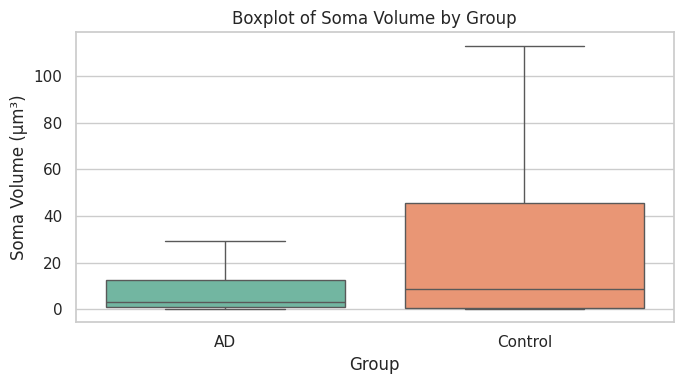

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')

metrics = ['soma_volume', 'soma_surface_area', 'soma_radius',
           'number_of_neurites', 'number_of_sections', 'number_of_segments',
           'mean_section_length', 'mean_segment_length', 'mean_local_bif_angle', 'n_bifs']


plt.figure(figsize=(7, 4))
sns.boxplot(x='group', y='soma_volume', data=filtered_no_outliers, palette='Set2', showfliers=False)
plt.xlabel('Group')
plt.ylabel('Soma Volume (µm\u00B3)')
plt.title(f'Boxplot of Soma Volume by Group')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3520360569.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='soma_surface_area', data=filtered_no_outliers, palette='Set2', showfliers=False)


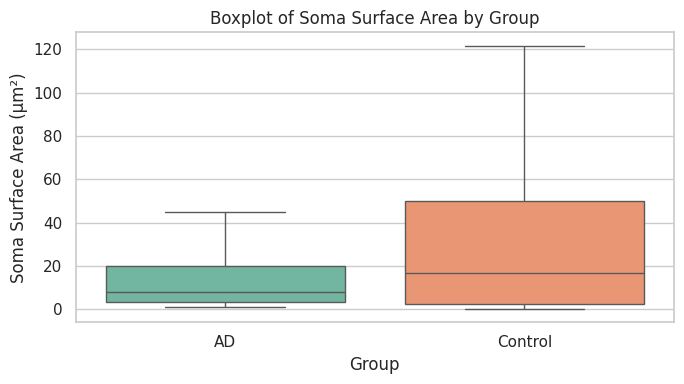

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='group', y='soma_surface_area', data=filtered_no_outliers, palette='Set2', showfliers=False)
plt.xlabel('Group')
plt.ylabel('Soma Surface Area (µm\u00B2)')
plt.title(f'Boxplot of Soma Surface Area by Group')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1504290884.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='soma_radius', data=filtered_no_outliers, palette='Set2', showfliers=False)


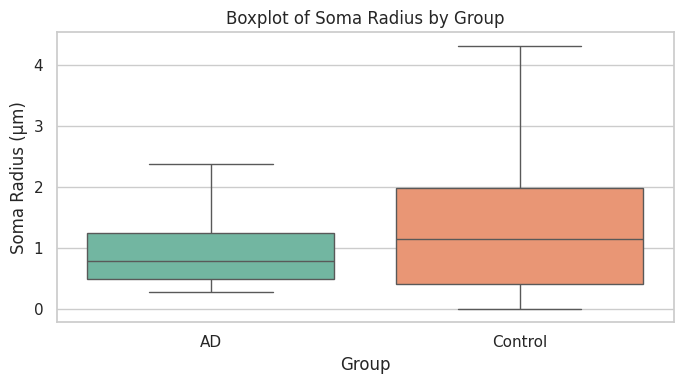

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='group', y='soma_radius', data=filtered_no_outliers, palette='Set2', showfliers=False)
plt.xlabel('Group')
plt.ylabel('Soma Radius (µm)')
plt.title(f'Boxplot of Soma Radius by Group')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2634400927.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='number_of_neurites', data=filtered_no_outliers, palette='Set2', showfliers=False)


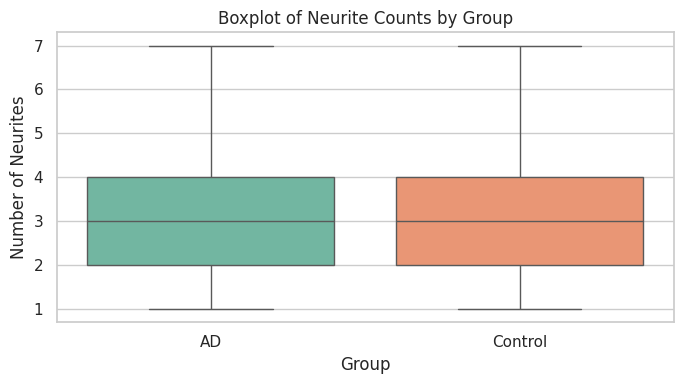

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='group', y='number_of_neurites', data=filtered_no_outliers, palette='Set2', showfliers=False)
plt.xlabel('Group')
plt.ylabel('Number of Neurites')
plt.title(f'Boxplot of Neurite Counts by Group')
plt.tight_layout()
plt.show()

/tmp/ipython-input-647613982.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='number_of_sections', data=filtered_no_outliers, palette='Set2', showfliers=False)


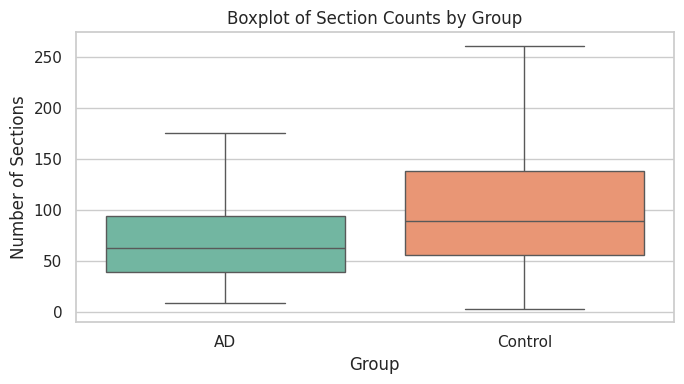

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='group', y='number_of_sections', data=filtered_no_outliers, palette='Set2', showfliers=False)
plt.xlabel('Group')
plt.ylabel('Number of Sections')
plt.title(f'Boxplot of Section Counts by Group')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2925929638.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='number_of_segments', data=filtered_no_outliers, palette='Set2', showfliers=False)


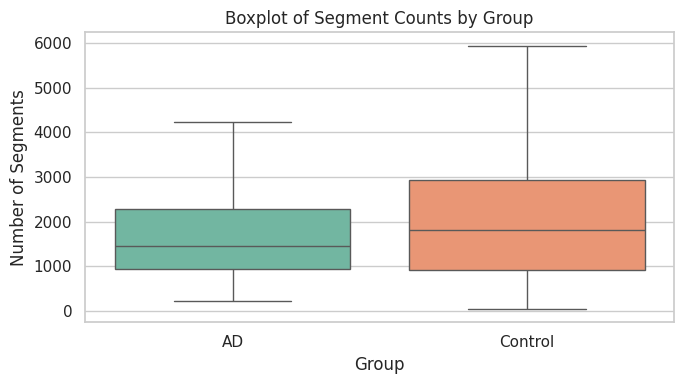

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='group', y='number_of_segments', data=filtered_no_outliers, palette='Set2', showfliers=False)
plt.xlabel('Group')
plt.ylabel('Number of Segments')
plt.title(f'Boxplot of Segment Counts by Group')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1499934849.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='mean_section_length', data=filtered_no_outliers, palette='Set2', showfliers=False)


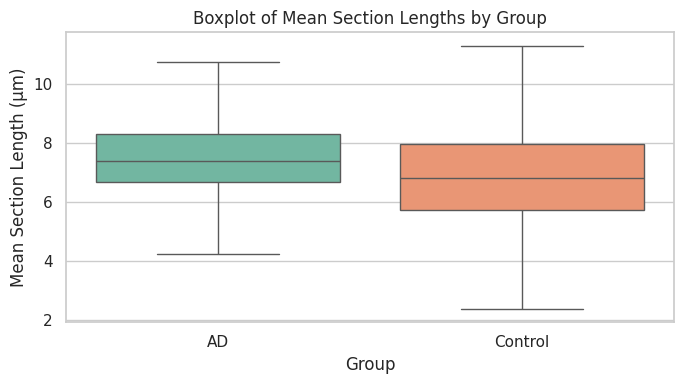

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='group', y='mean_section_length', data=filtered_no_outliers, palette='Set2', showfliers=False)
plt.xlabel('Group')
plt.ylabel('Mean Section Length (µm)')
plt.title(f'Boxplot of Mean Section Lengths by Group')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3013726694.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='mean_segment_length', data=filtered_no_outliers, palette='Set2', showfliers=False)


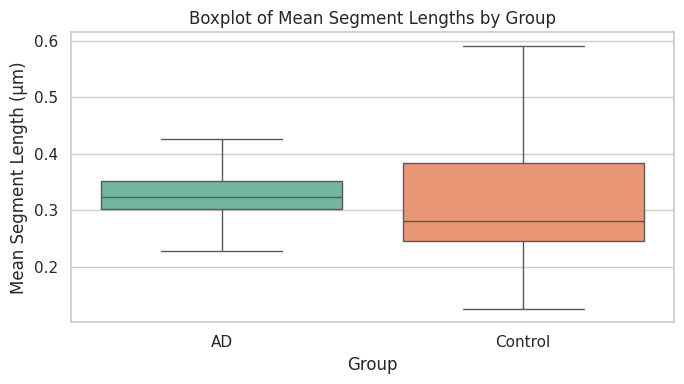

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='group', y='mean_segment_length', data=filtered_no_outliers, palette='Set2', showfliers=False)
plt.xlabel('Group')
plt.ylabel('Mean Segment Length (µm)')
plt.title(f'Boxplot of Mean Segment Lengths by Group')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2016998588.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='mean_local_bif_angle', data=filtered_no_outliers, palette='Set2', showfliers=False)


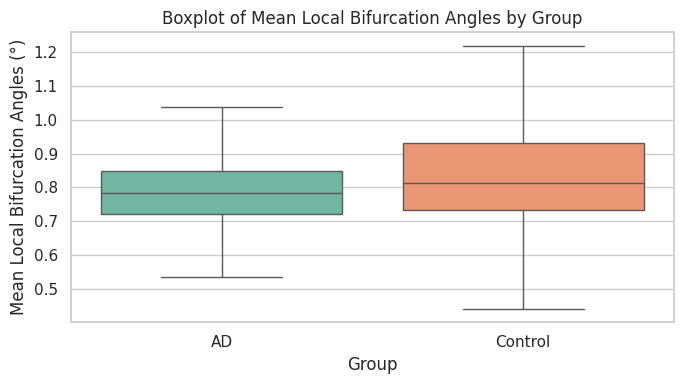

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='group', y='mean_local_bif_angle', data=filtered_no_outliers, palette='Set2', showfliers=False)
plt.xlabel('Group')
plt.ylabel('Mean Local Bifurcation Angles (°)')
plt.title(f'Boxplot of Mean Local Bifurcation Angles by Group')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1154835024.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='n_bifs', data=filtered_no_outliers, palette='Set2', showfliers=False)


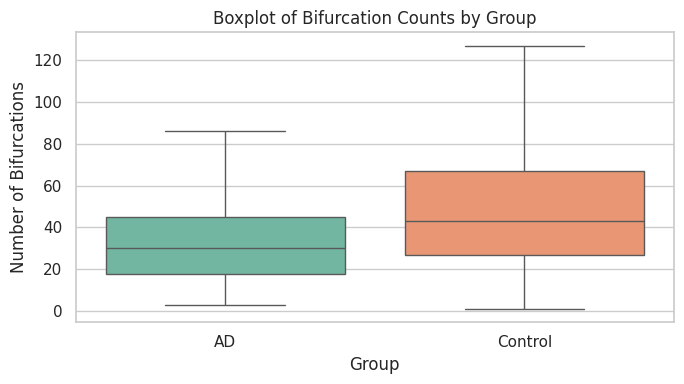

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='group', y='n_bifs', data=filtered_no_outliers, palette='Set2', showfliers=False)
plt.xlabel('Group')
plt.ylabel('Number of Bifurcations')
plt.title(f'Boxplot of Bifurcation Counts by Group')
plt.tight_layout()
plt.show()

/tmp/ipykernel_10682/1281518300.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=30, title_fontsize=35)


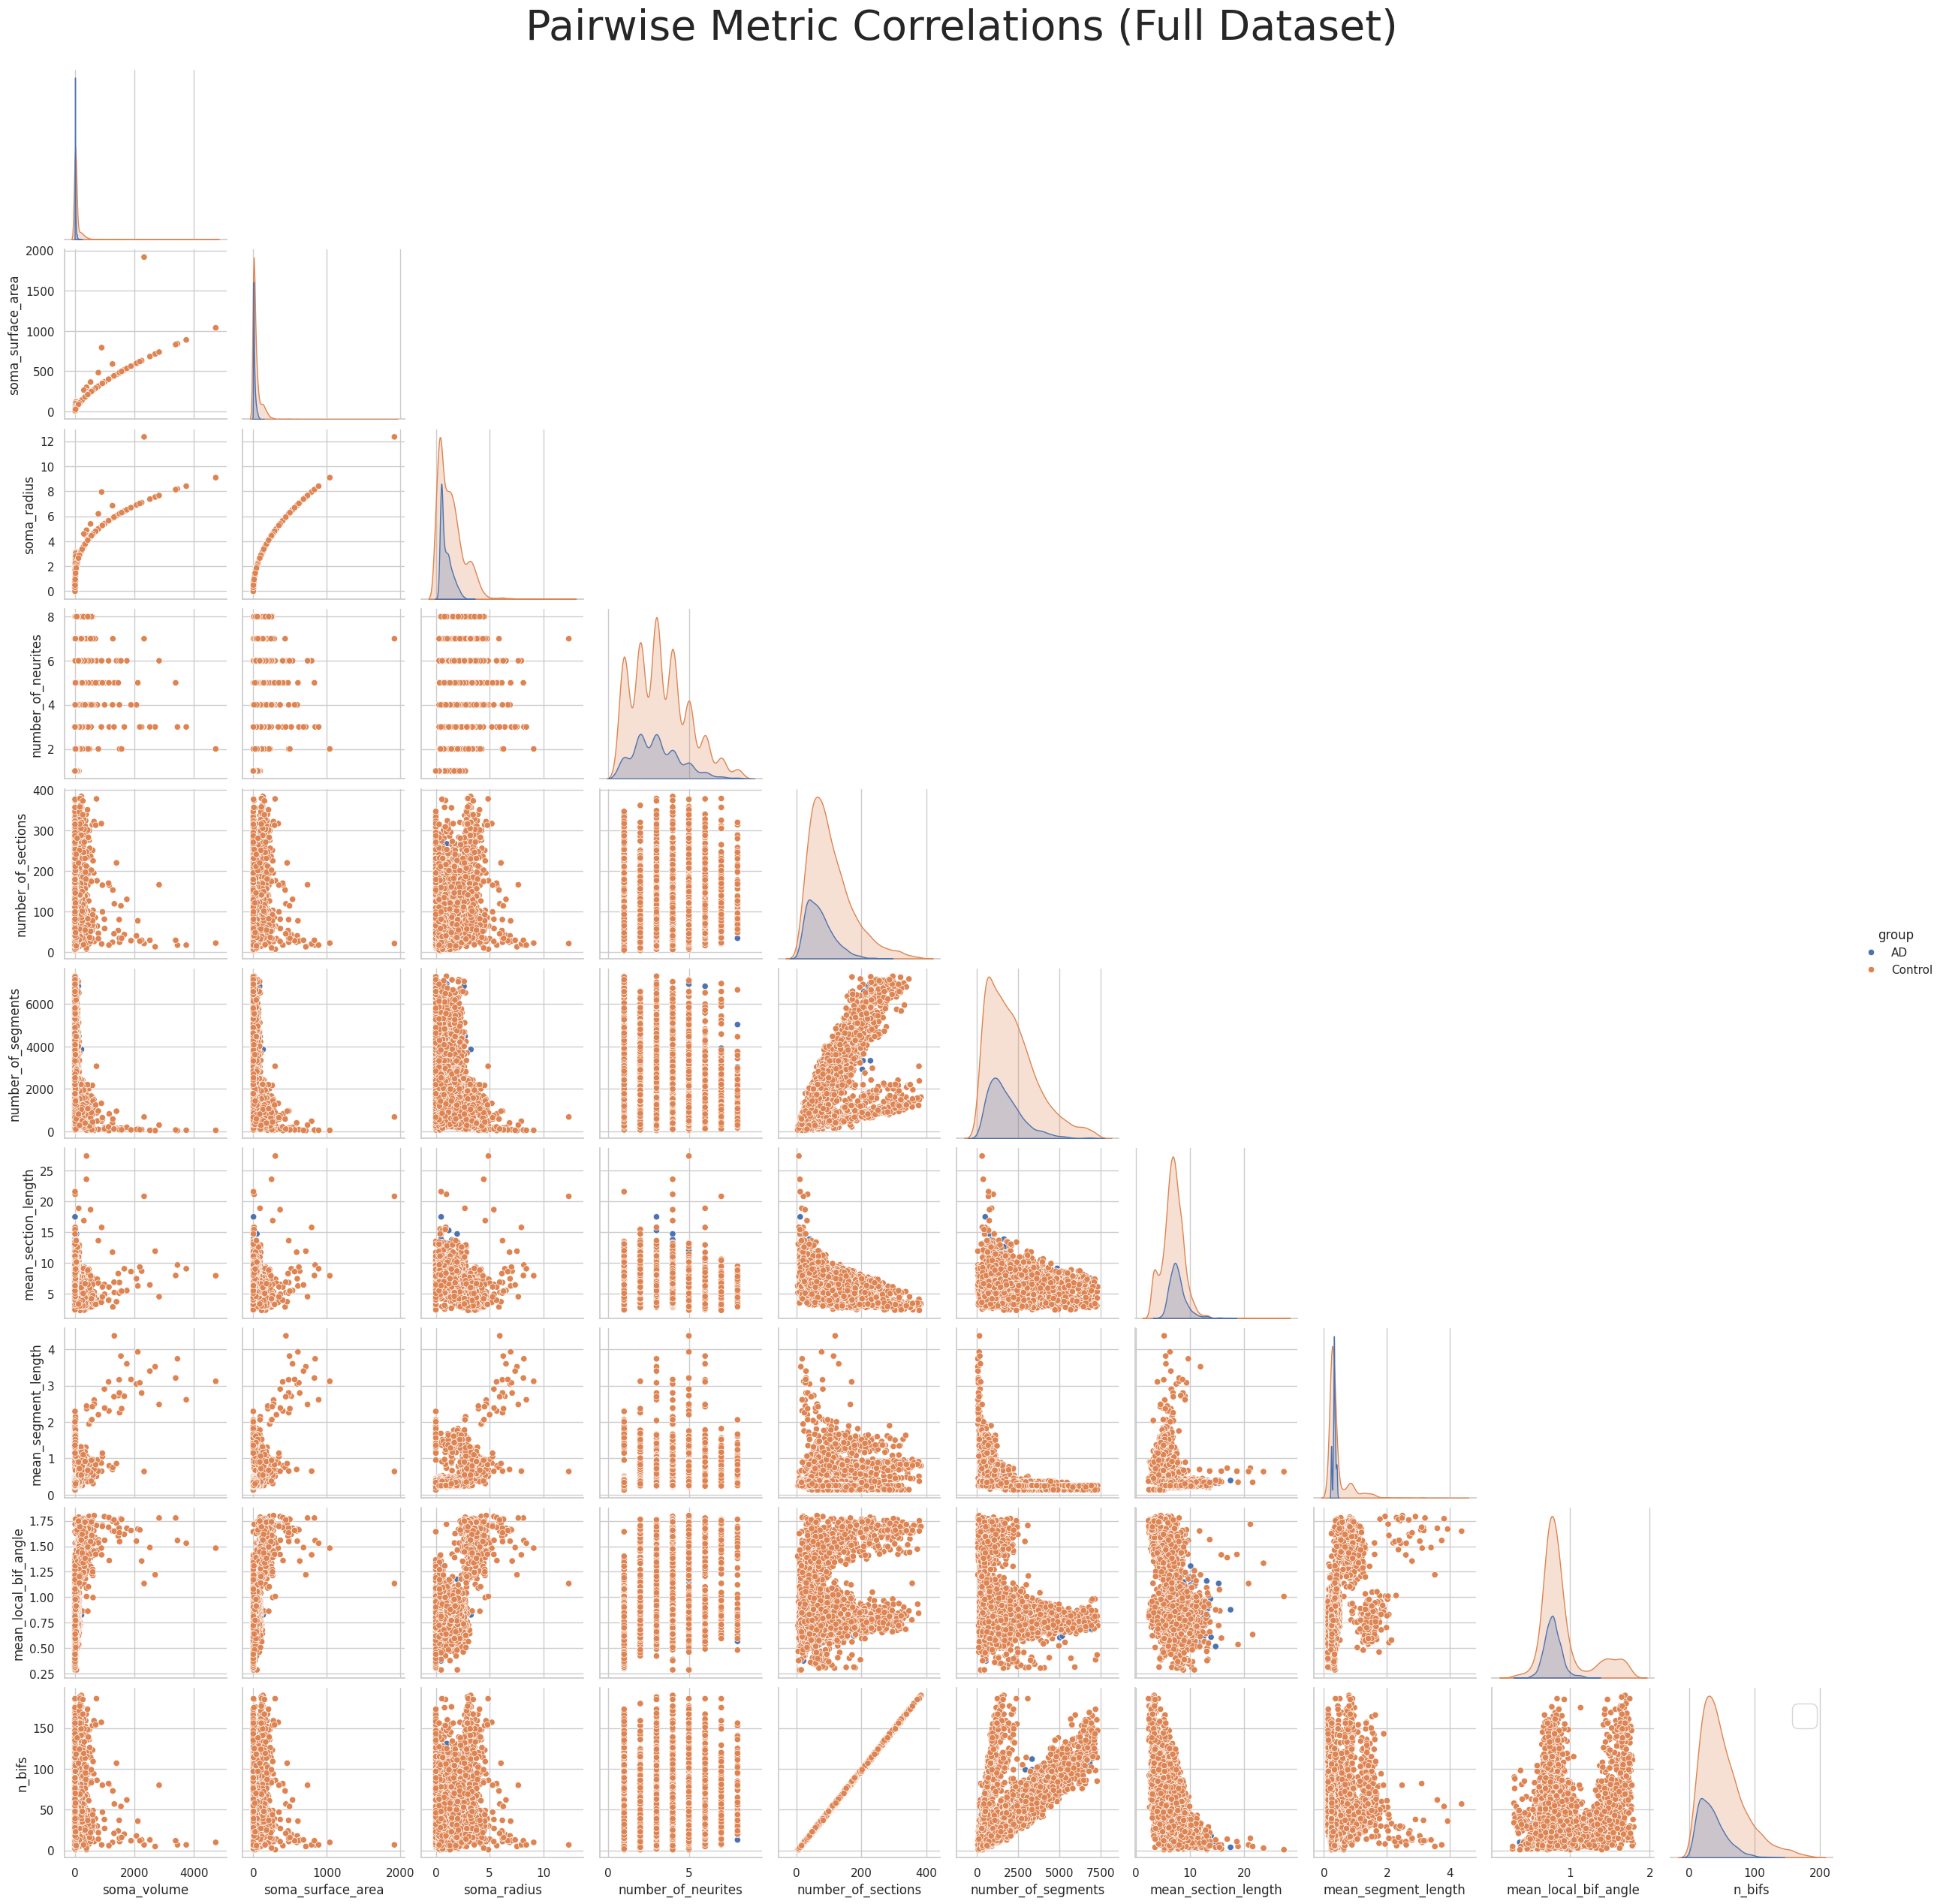

In [ ]:
sns.pairplot(filtered_no_outliers[metrics + ['group']], hue='group', diag_kind='kde', corner=True)
plt.suptitle('Pairwise Metric Correlations (Full Dataset)', y=1.02, fontsize = 40)
plt.legend(fontsize=30, title_fontsize=35)

/tmp/ipykernel_10682/672546819.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=30, title_fontsize=35)


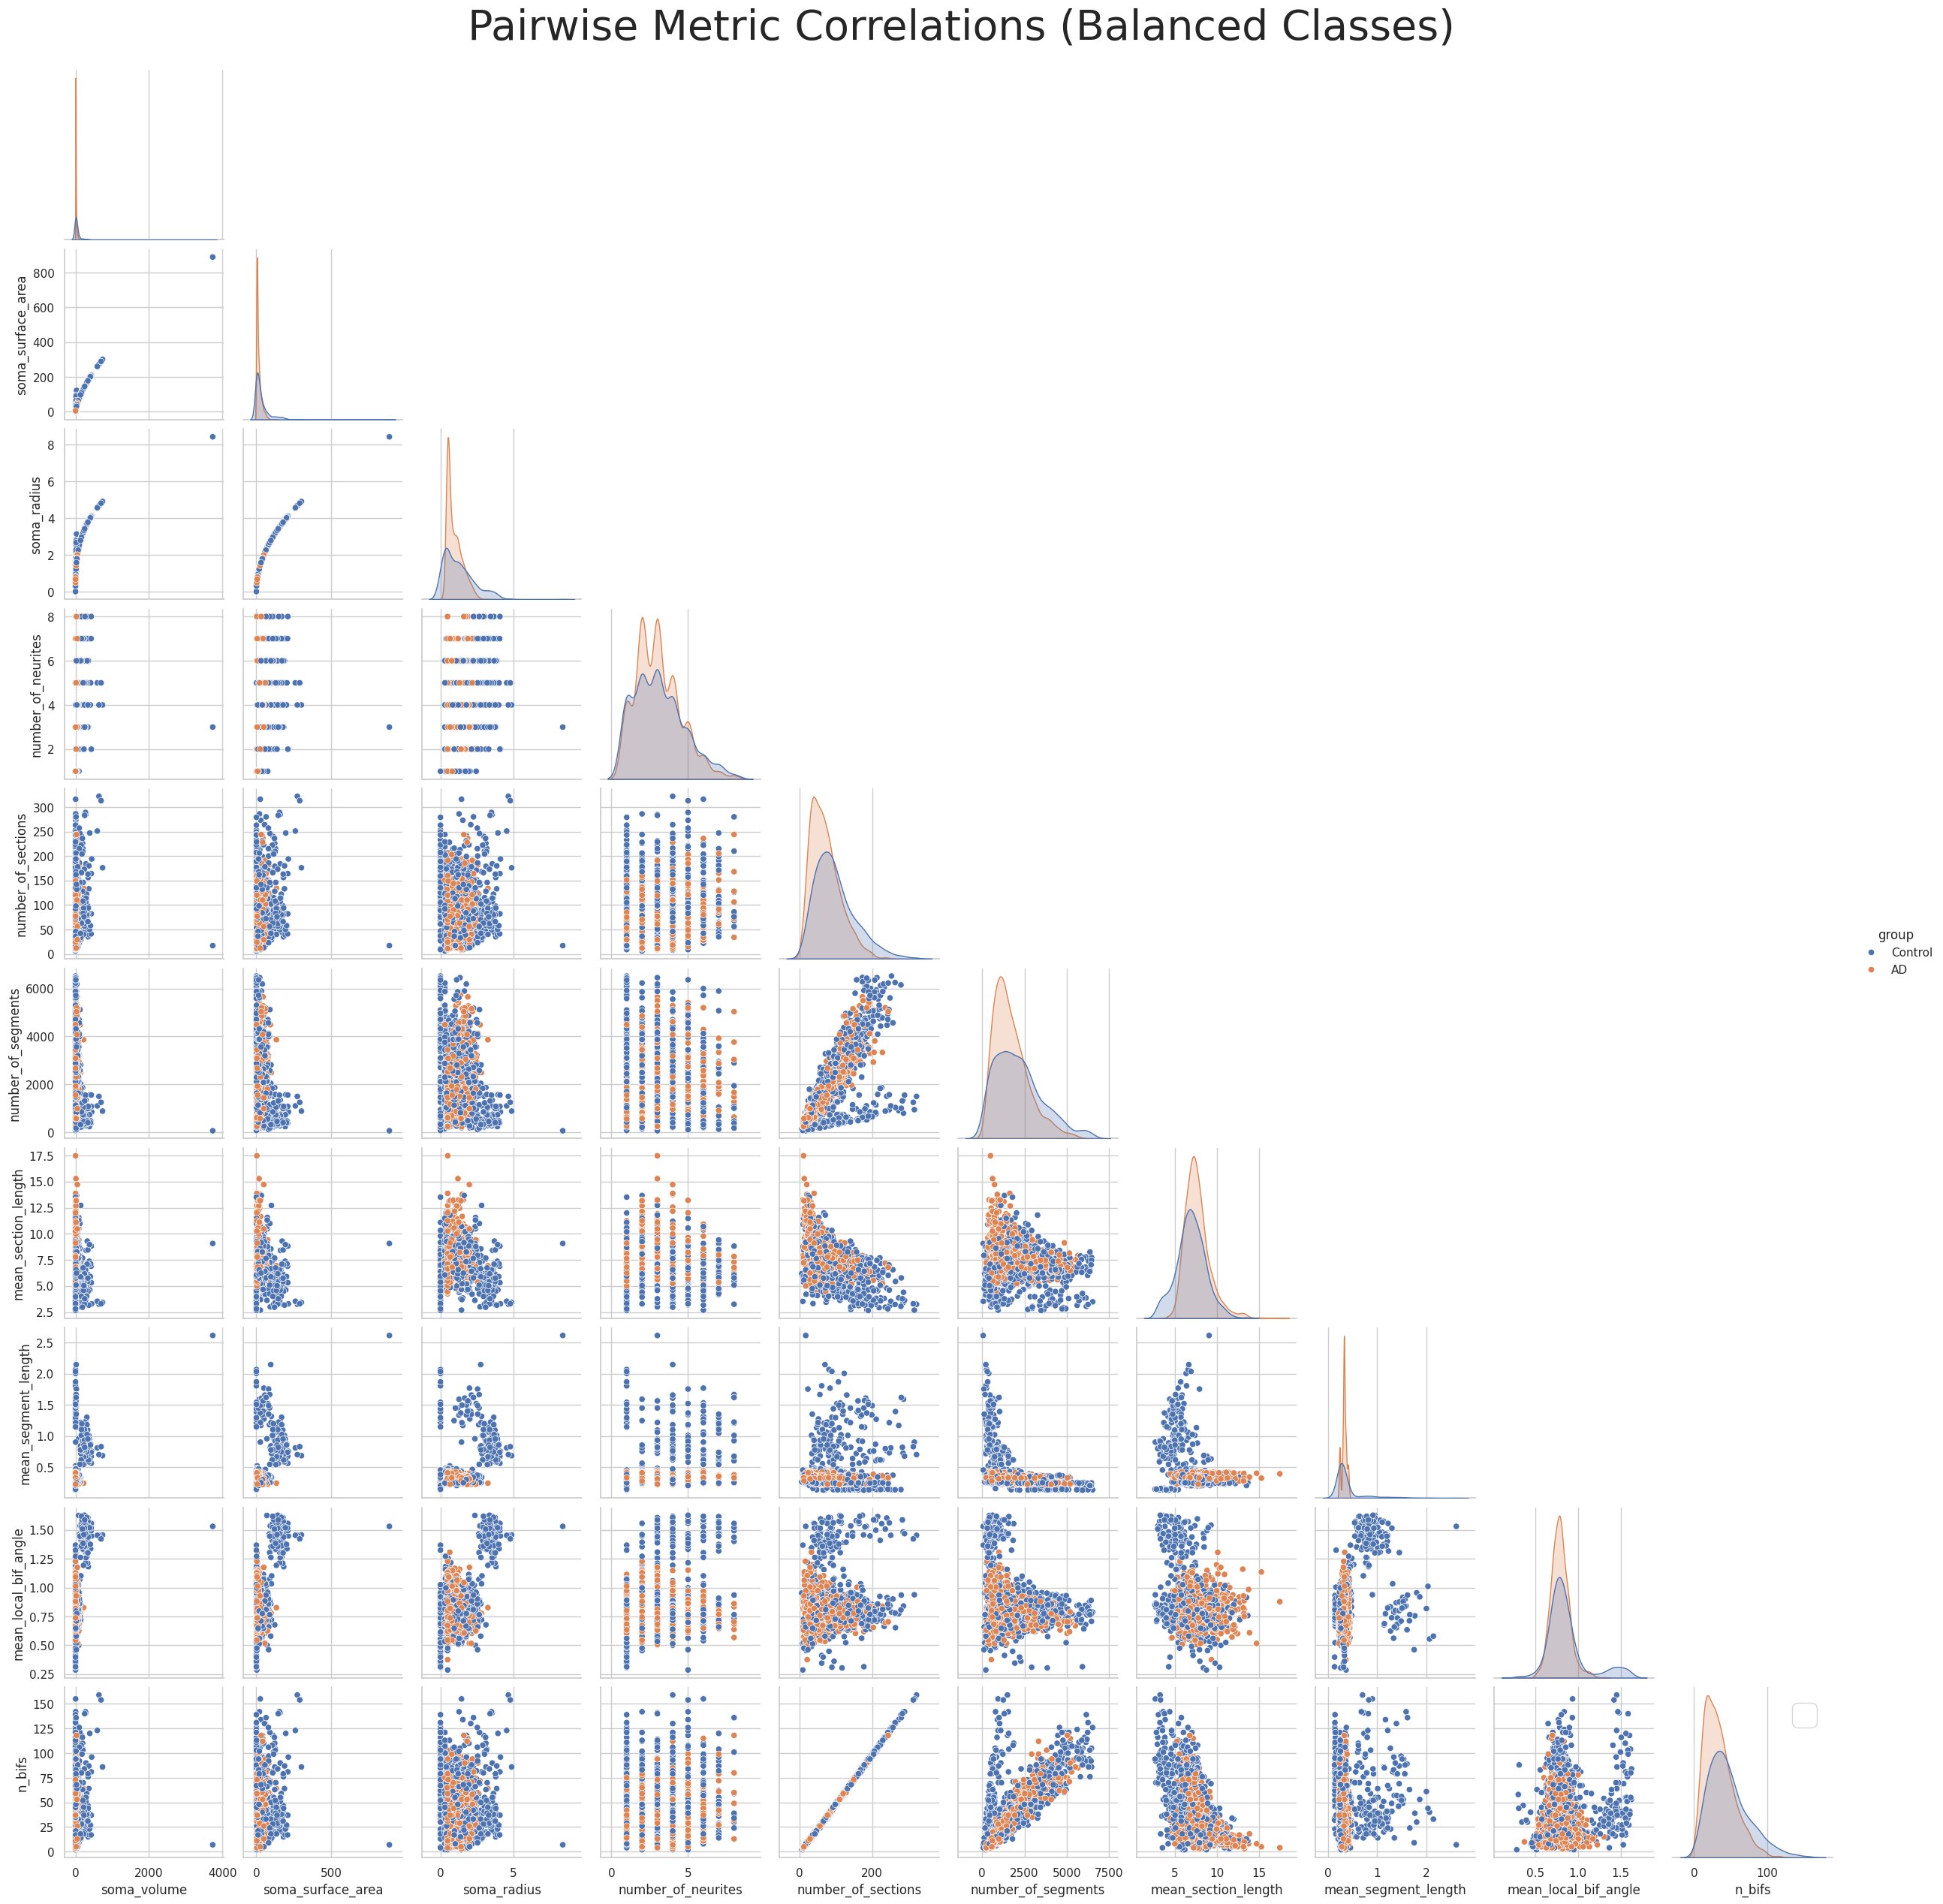

In [ ]:
sns.pairplot(filtered_no_outliers_balanced[metrics + ['group']], hue='group', diag_kind='kde', corner=True)
plt.suptitle('Pairwise Metric Correlations (Balanced Classes)', y=1.02, fontsize = 40)
plt.legend(fontsize=30, title_fontsize=35)
plt.show()

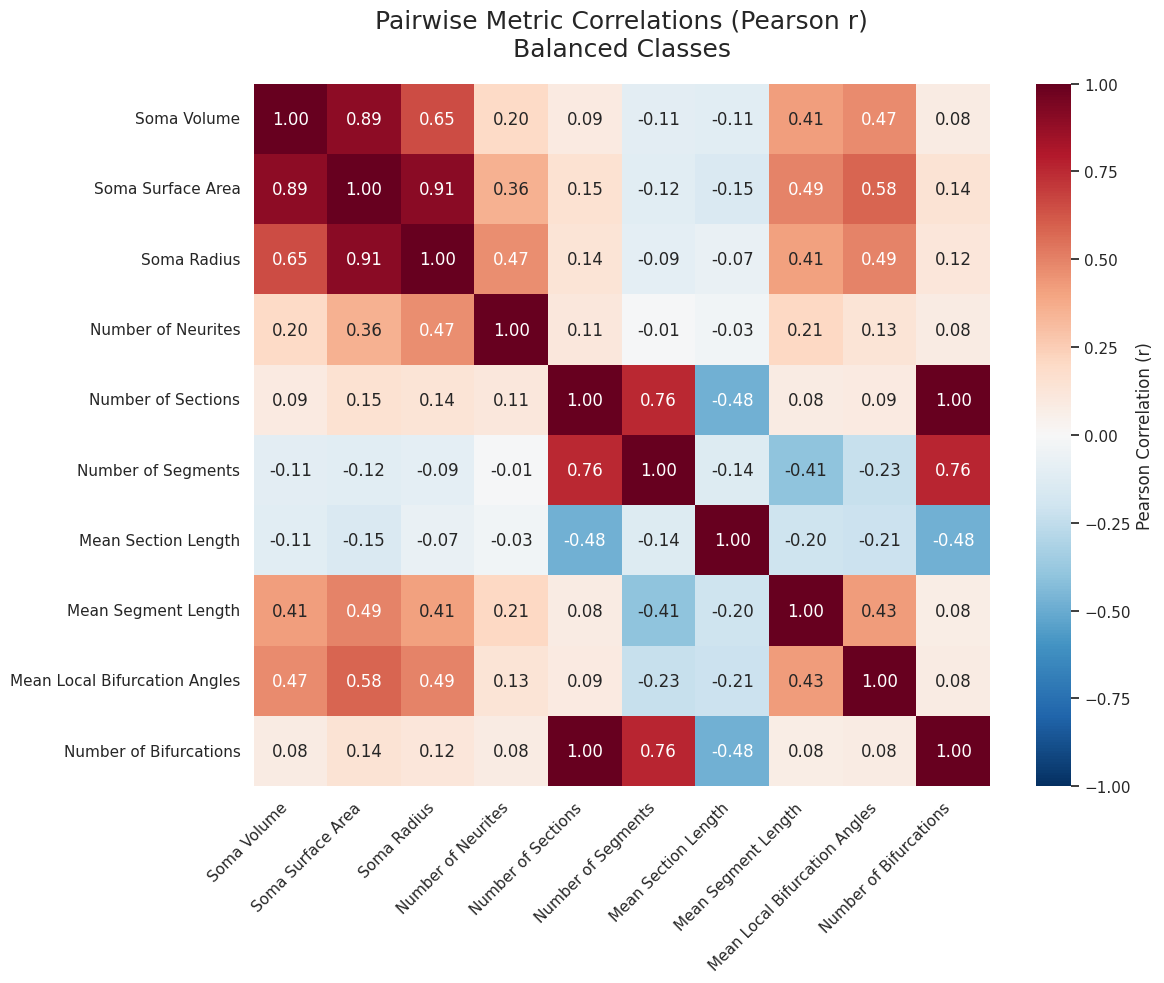

In [ ]:
# 1. Calculate the Pearson correlation matrix
corr_matrix = filtered_no_outliers_balanced[metrics].corr()

# 2. Clean names
corr_matrix.index = [clean_metric_name(m) for m in corr_matrix.index]
corr_matrix.columns = [clean_metric_name(m) for m in corr_matrix.columns]

# 3. Plot the Heatmap
plt.figure(figsize=(12, 10))

# The cbar_kws argument allows you to pass parameters to the color bar
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Pearson Correlation (r)'} # This adds the right-side label
)

plt.title('Pairwise Metric Correlations (Pearson r)\nBalanced Classes', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0) # Keeps metric names horizontal for readability
plt.tight_layout()
plt.show()

In [ ]:
r2_table_full.to_csv('r2_table_full.csv', index=False)

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score

features = [
    'soma_volume', 'soma_surface_area', 'soma_radius',
    'number_of_neurites', 'number_of_sections', 'number_of_segments',
    'mean_section_length', 'mean_segment_length', 'mean_local_bif_angle', 'n_bifs'
]

df_clean = df.dropna(subset=features + ['group']).copy()

df_clean['label'] = df_clean['group'].map({'Control': 0, 'AD': 1})

ad_df = df_clean[df_clean['label'] == 1]
control_df = df_clean[df_clean['label'] == 0]

RANDOM_SEED = 42

control_downsampled = control_df.sample(n=len(ad_df), random_state=RANDOM_SEED)
df_balanced = pd.concat([ad_df, control_downsampled], axis=0).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

X = df_balanced[features]
y = df_balanced['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Balanced shape:", df_balanced.shape)
print("Value counts:\n", y.value_counts())


Balanced shape: (2352, 13)
Value counts:
 label
0    1176
1    1176
Name: count, dtype: int64


In [ ]:
z_scores2 = df_balanced[metrics].apply(zscore)

filtered_no_outliers_balanced = df_balanced[(z_scores2.abs() <= 3).all(axis=1)]

In [ ]:
filtered_no_outliers_balanced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2200 entries, 1 to 2351
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   neuron_name           2200 non-null   object 
 1   group                 2200 non-null   object 
 2   soma_volume           2200 non-null   float64
 3   soma_surface_area     2200 non-null   float64
 4   soma_radius           2200 non-null   float64
 5   number_of_neurites    2200 non-null   int64  
 6   number_of_sections    2200 non-null   int64  
 7   number_of_segments    2200 non-null   int64  
 8   mean_section_length   2200 non-null   float64
 9   mean_segment_length   2200 non-null   float64
 10  mean_local_bif_angle  2200 non-null   float64
 11  n_bifs                2200 non-null   int64  
 12  label                 2200 non-null   int64  
dtypes: float64(6), int64(5), object(2)
memory usage: 240.6+ KB


In [ ]:
df_balanced['group'].value_counts()

,count
group,
Control,1176
AD,1176


In [ ]:
filtered_no_outliers_balanced['group'].value_counts()

,count
group,
AD,1168
Control,1032


In [ ]:
r2_table_balanced = compute_r2_matrix(filtered_no_outliers_balanced, metrics)
print(r2_table_balanced.round(2))

                      soma_volume  soma_surface_area  soma_radius  \
soma_volume                  1.00               0.82         0.44   
soma_surface_area            0.82               1.00         0.81   
soma_radius                  0.44               0.81         1.00   
number_of_neurites           0.03               0.11         0.21   
number_of_sections           0.00               0.01         0.01   
number_of_segments           0.02               0.02         0.01   
mean_section_length          0.01               0.02         0.01   
mean_segment_length          0.29               0.34         0.20   
mean_local_bif_angle         0.22               0.35         0.28   
n_bifs                       0.00               0.01         0.01   

                      number_of_neurites  number_of_sections  \
soma_volume                         0.03                0.00   
soma_surface_area                   0.11                0.01   
soma_radius                         0.21        

In [ ]:
r2_table_balanced.to_csv('r2_table_balanced.csv', index=False)

In [ ]:
for metric in metrics:
    group1 = filtered_no_outliers_balanced[filtered_no_outliers_balanced['group'] == 'Control'][metric]
    group2 = filtered_no_outliers_balanced[filtered_no_outliers_balanced['group'] == 'AD'][metric]

    stat, p_value = ttest_ind(group1, group2, equal_var=False)

    print(f"{metric}: t = {stat:.3f}, p = {p_value:.4f}")

soma_volume: t = 7.579, p = 0.0000
soma_surface_area: t = 10.927, p = 0.0000
soma_radius: t = 9.383, p = 0.0000
number_of_neurites: t = 2.445, p = 0.0146
number_of_sections: t = 11.998, p = 0.0000
number_of_segments: t = 7.758, p = 0.0000
mean_section_length: t = -9.289, p = 0.0000
mean_segment_length: t = 7.663, p = 0.0000
mean_local_bif_angle: t = 10.773, p = 0.0000
n_bifs: t = 11.962, p = 0.0000


In [ ]:
def clean_metric_name(name):
    if name == 'n_bifs':
        name = 'Number_of_Bifurcations'
    elif name == 'mean_local_bif_angle':
        name = 'Mean_Local_Bifurcation_Angles'
    else:
        name = name.replace('bif', 'bifurcation')

    name = name.replace('_', ' ').title().replace(' Of ', ' of ')
    return name

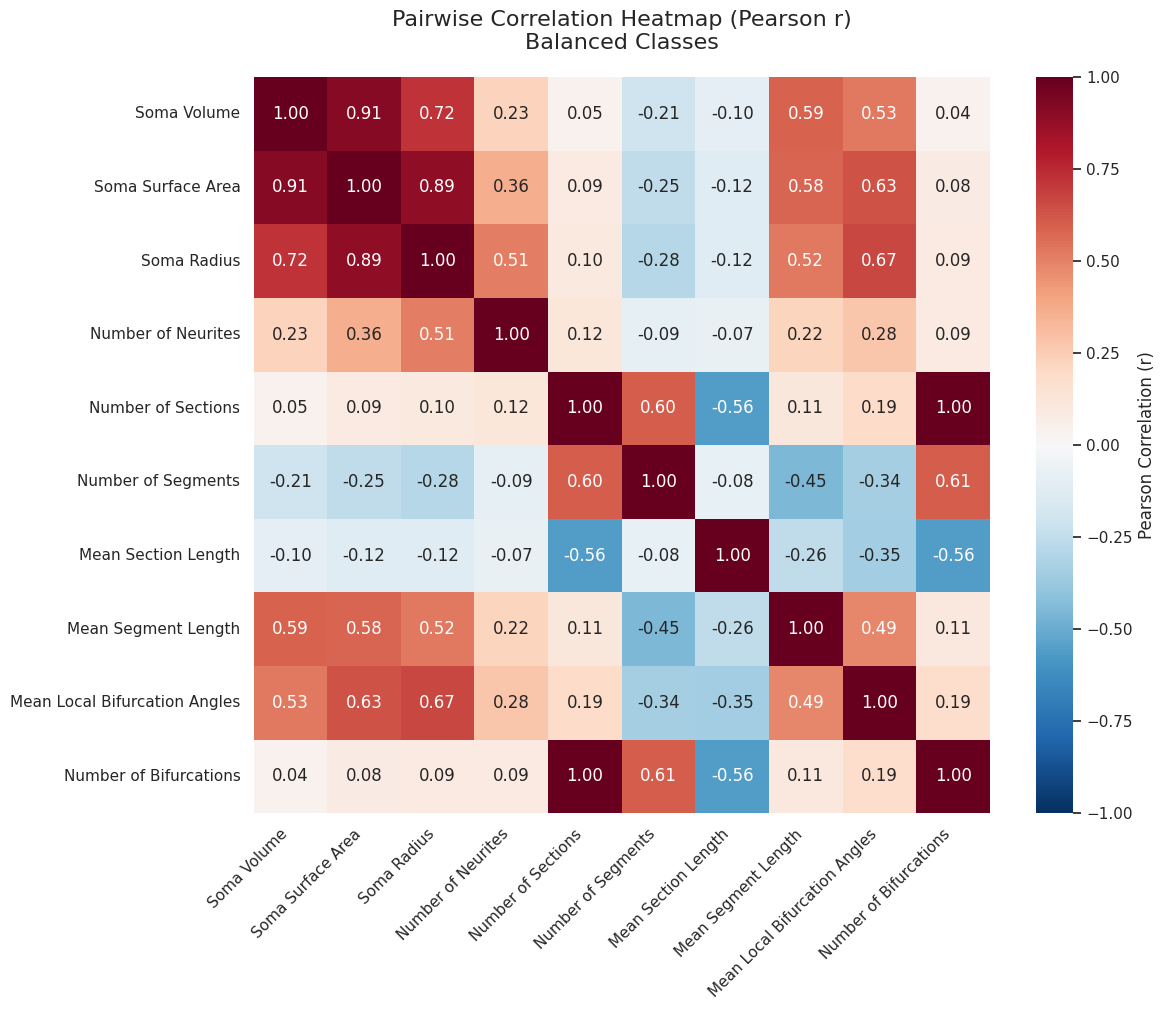

In [ ]:
# 1. Calculate the Pearson correlation (r) instead of R^2 to show direction
corr_matrix_full = filtered_no_outliers[metrics].corr()

# 2. Apply your cleaning function to index and columns
corr_matrix_full_clean = corr_matrix_full.copy()
corr_matrix_full_clean.index = corr_matrix_full_clean.index.map(clean_metric_name)
corr_matrix_full_clean.columns = corr_matrix_full_clean.columns.map(clean_metric_name)

# 3. Plot the Heatmap
plt.figure(figsize=(12, 10))

# Use 'RdBu_r' (Red-Blue) which is standard for showing positive/negative correlations
sns.heatmap(
    corr_matrix_full_clean.astype(float),
    annot=True,
    cmap='RdBu_r',
    center=0,      # Ensures 0 (no correlation) is white
    vmin=-1,       # Minimum correlation
    vmax=1,        # Maximum correlation
    fmt=".2f",
    square=True,
    cbar_kws={'label': 'Pearson Correlation (r)'} # Adds the right-side Y-axis label
)

plt.title('Pairwise Correlation Heatmap (Pearson r)\nBalanced Classes', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
!pip install shap

import shap
import matplotlib.pyplot as plt


In [ ]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_log = cross_val_predict(logreg, X_scaled, y, cv=cv)
acc_scores = cross_val_score(logreg, X_scaled, y, cv=cv, scoring='accuracy')
print(f'Logistic Regression 5-fold CV Accuracy: {np.mean(acc_scores):.3f} ± {np.std(acc_scores):.3f}')

Logistic Regression 5-fold CV Accuracy: 0.689 ± 0.030


In [ ]:
print("Classification Report:")
print(classification_report(y, y_pred_log, target_names=['Control', '5xFAD']))

print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_log))

Classification Report:
              precision    recall  f1-score   support

     Control       0.73      0.60      0.66      1176
       5xFAD       0.66      0.78      0.72      1176

    accuracy                           0.69      2352
   macro avg       0.70      0.69      0.69      2352
weighted avg       0.70      0.69      0.69      2352

Confusion Matrix:
[[702 474]
 [257 919]]


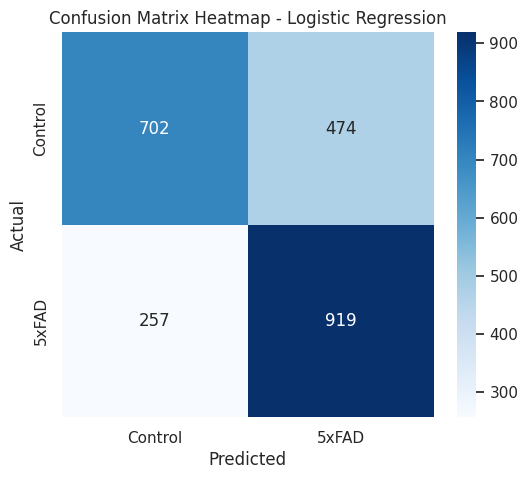

In [ ]:
conf_matrix = confusion_matrix(y, y_pred_log)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Control', '5xFAD'], yticklabels=['Control', '5xFAD'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap - Logistic Regression')

plt.show()

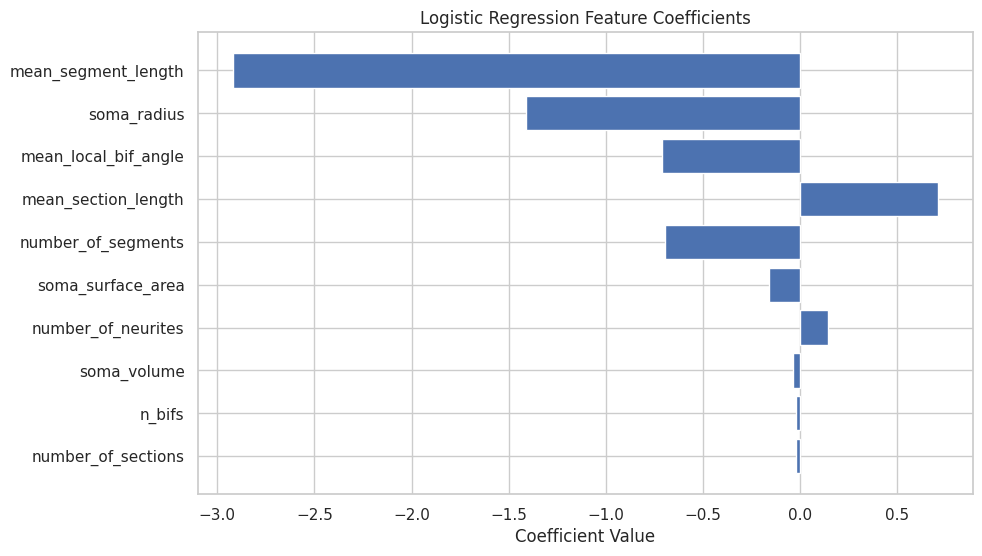

In [ ]:
logreg.fit(X_scaled, y)
coef = logreg.coef_[0]
features_names = X.columns
sorted_idx = np.argsort(np.abs(coef))[::-1]

plt.figure(figsize=(10,6))
plt.barh(features_names[sorted_idx], coef[sorted_idx])
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Feature Coefficients')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict

def plot_roc_curve(clf, X, y, cv, title):
    y_probas = cross_val_predict(clf, X, y, cv=cv, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y, y_probas)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Chance level')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right', fontsize=10, title_fontsize=15)
    plt.show()

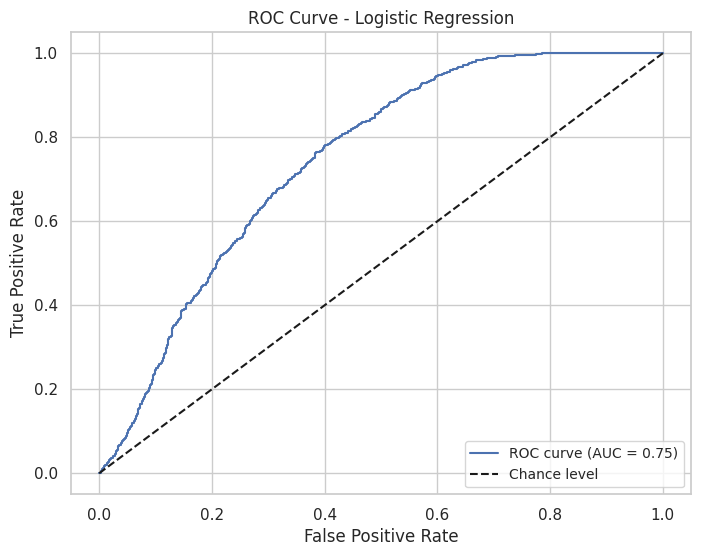

In [ ]:
plot_roc_curve(logreg, X_scaled, y, cv, 'ROC Curve - Logistic Regression')

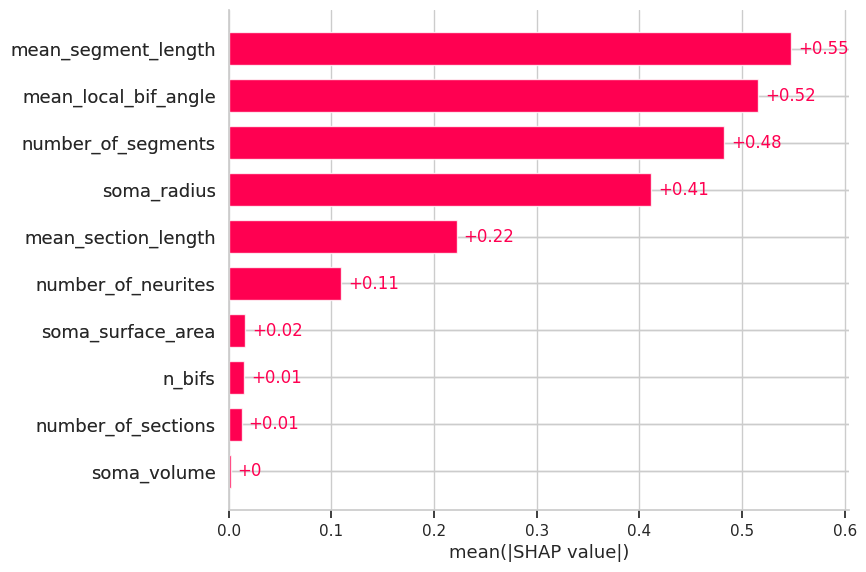

In [ ]:
import shap

X_display = pd.DataFrame(X_scaled, columns=features)

explainer = shap.LinearExplainer(logreg, X_display)
shap_values = explainer.shap_values(X_display)

expl = shap.Explanation(values=shap_values, data=X_display, feature_names=features)
shap.plots.bar(expl)


In [ ]:
ax = shap.plots.bar(expl, show=False)

ax.set_title("SHAP Feature Importance - Logistic Regression")

fig = ax.figure

fig.tight_layout()
fig.savefig("shap_summary_logreg_bar.png", dpi=300)
plt.close(fig)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
import matplotlib.pyplot as plt
import numpy as np

rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_rand = cross_val_predict(rf, X_scaled, y, cv=cv)

acc_scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
print(f'Random Forest 5-fold CV Accuracy: {np.mean(acc_scores):.3f} ± {np.std(acc_scores):.3f}')

Random Forest 5-fold CV Accuracy: 0.906 ± 0.018


In [ ]:
print("Classification Report:")
print(classification_report(y, y_pred_rand, target_names=['Control', '5xFAD']))

print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_rand))

Classification Report:
              precision    recall  f1-score   support

     Control       0.91      0.90      0.91      1176
       5xFAD       0.90      0.91      0.91      1176

    accuracy                           0.91      2352
   macro avg       0.91      0.91      0.91      2352
weighted avg       0.91      0.91      0.91      2352

Confusion Matrix:
[[1061  115]
 [ 106 1070]]


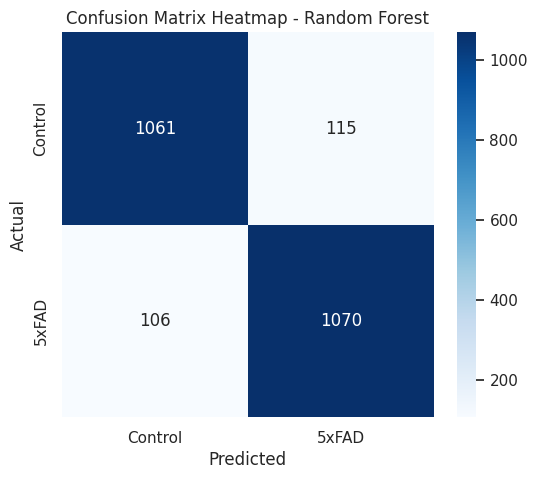

In [ ]:
conf_matrix = confusion_matrix(y, y_pred_rand)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Control', '5xFAD'], yticklabels=['Control', '5xFAD'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap - Random Forest')

plt.show()

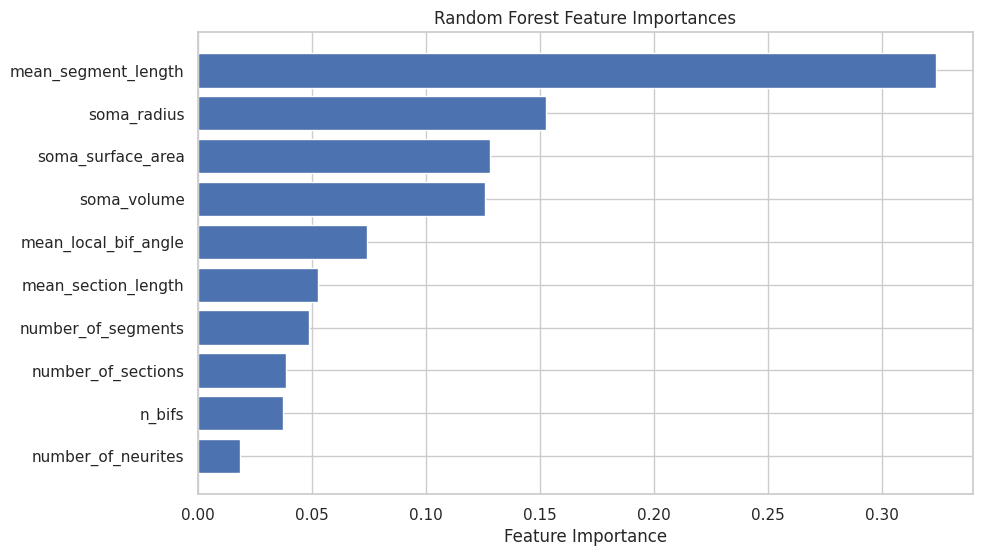

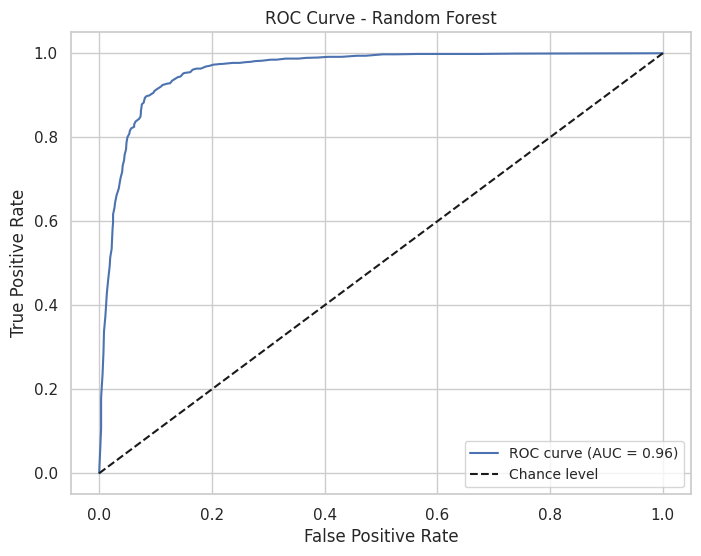

In [ ]:
rf.fit(X_scaled, y)

importances = rf.feature_importances_
features_names = X.columns
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.barh(features_names[sorted_idx], importances[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()
plt.show()

plot_roc_curve(rf, X_scaled, y, cv, 'ROC Curve - Random Forest')

100%|===================| 4684/4704 [02:36<00:00]       

SHAP values shape: (2352, 10, 2)


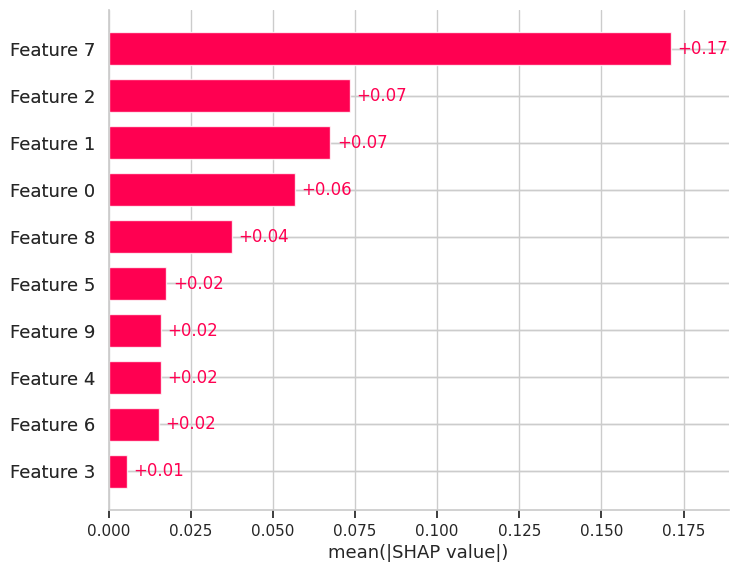

In [ ]:
X_shap = X_scaled
feature_names = [
    'soma_volume', 'soma_surface_area', 'soma_radius',
    'number_of_neurites', 'number_of_sections', 'number_of_segments',
    'mean_section_length', 'mean_segment_length', 'mean_local_bif_angle', 'n_bifs'
]

explainer = shap.Explainer(rf, X_scaled)

shap_values = explainer(X_scaled, check_additivity = False)

print("SHAP values shape:", shap_values.values.shape)

positive_class_shap = shap_values.values[:, :, 1]

positive_class_exp = shap.Explanation(
    values=positive_class_shap,
    base_values=shap_values.base_values[:, 1],
    data=X_scaled,
    feature_names=shap_values.feature_names
)

shap.plots.bar(positive_class_exp)

In [ ]:
ax = shap.plots.bar(positive_class_exp, show=False)

ax.set_title("SHAP Feature Importance - Random Forest")

fig = ax.figure

fig.tight_layout()
fig.savefig("shap_summary_rf_bar.png", dpi=300)
plt.close(fig)


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_gb = cross_val_predict(gb, X_scaled, y, cv=cv)

acc_scores = cross_val_score(gb, X_scaled, y, cv=cv, scoring='accuracy')
print(f'Gradient Boosting 5-fold CV Accuracy: {np.mean(acc_scores):.3f} ± {np.std(acc_scores):.3f}')

Gradient Boosting 5-fold CV Accuracy: 0.910 ± 0.011


In [ ]:
print("Classification Report:")
print(classification_report(y, y_pred_gb, target_names=['Control', '5xFAD']))

print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_gb))

Classification Report:
              precision    recall  f1-score   support

     Control       0.93      0.89      0.91      1176
       5xFAD       0.90      0.93      0.91      1176

    accuracy                           0.91      2352
   macro avg       0.91      0.91      0.91      2352
weighted avg       0.91      0.91      0.91      2352

Confusion Matrix:
[[1049  127]
 [  85 1091]]


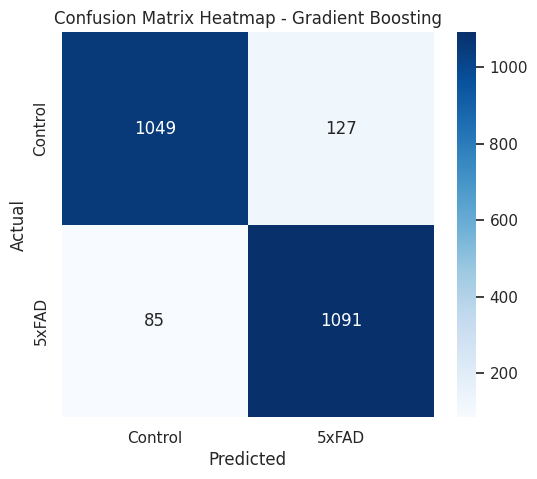

In [ ]:
conf_matrix = confusion_matrix(y, y_pred_gb)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Control', '5xFAD'], yticklabels=['Control', '5xFAD'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap - Gradient Boosting')

plt.show()

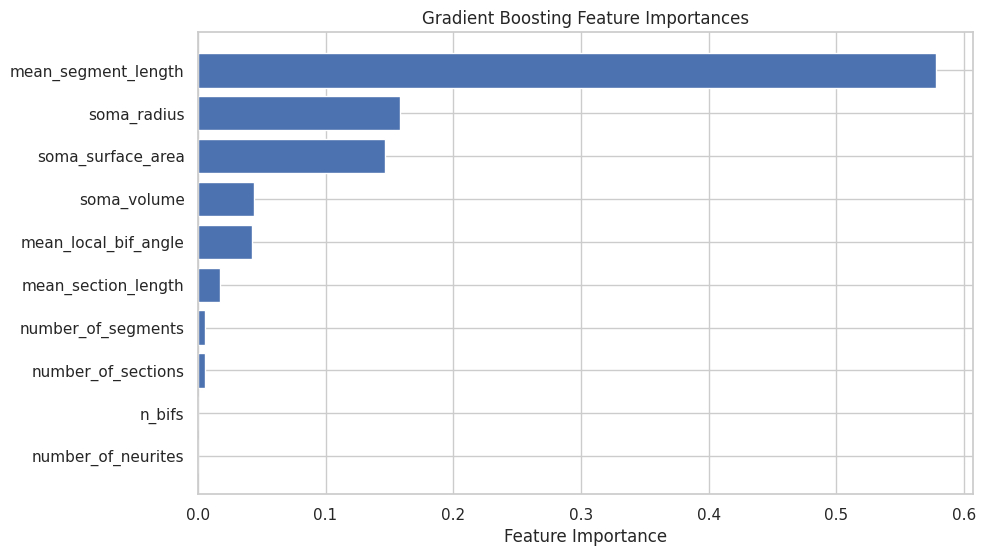

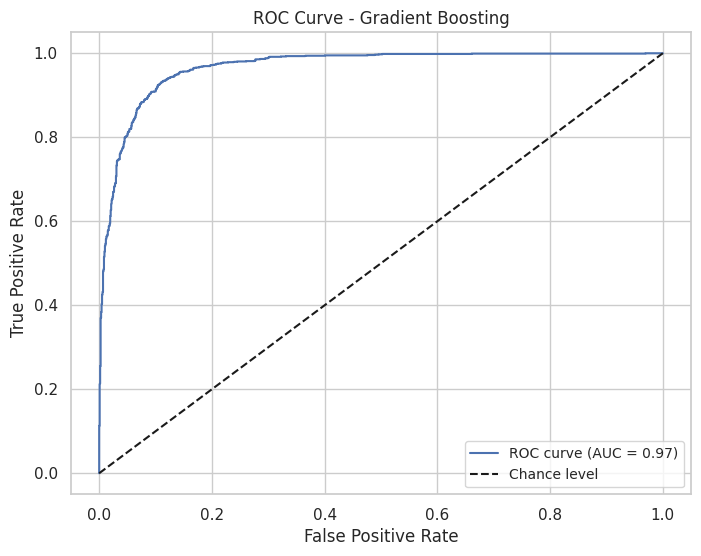

In [ ]:
gb.fit(X_scaled, y)

importances = gb.feature_importances_
features_names = X.columns
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.barh(features_names[sorted_idx], importances[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Gradient Boosting Feature Importances')
plt.gca().invert_yaxis()
plt.show()

plot_roc_curve(gb, X_scaled, y, cv, 'ROC Curve - Gradient Boosting')

SHAP values shape: (2352, 10)


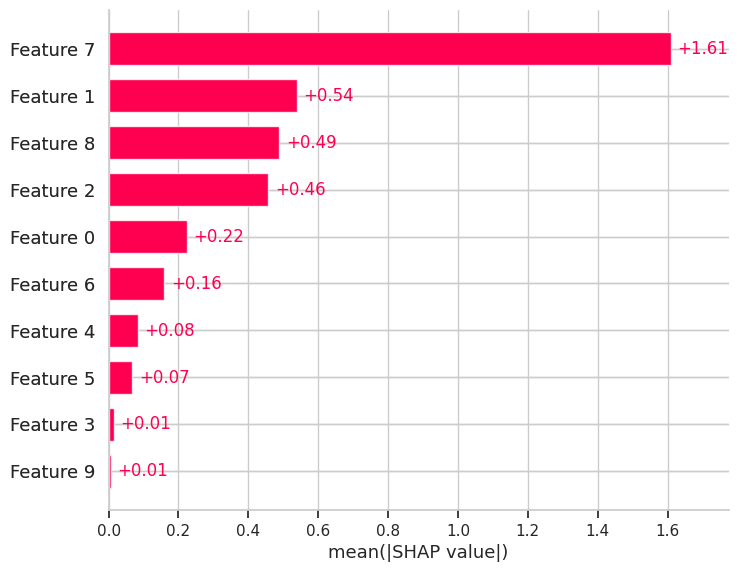

In [ ]:
explainer = shap.Explainer(gb, X_scaled)

shap_values = explainer(X_scaled, check_additivity = False)

print("SHAP values shape:", shap_values.values.shape)

positive_class_shap = shap_values.values

positive_class_exp_gb = shap.Explanation(
    values=positive_class_shap,
    base_values=shap_values.base_values,
    data=X_scaled,
    feature_names=shap_values.feature_names
)

shap.plots.bar(positive_class_exp_gb)

In [ ]:
ax = shap.plots.bar(positive_class_exp_gb, show=False)

ax.set_title("SHAP Feature Importance - Gradient Boosting")

fig = ax.figure

fig.tight_layout()
fig.savefig("shap_summary_gb_bar.png", dpi=300)
plt.close(fig)

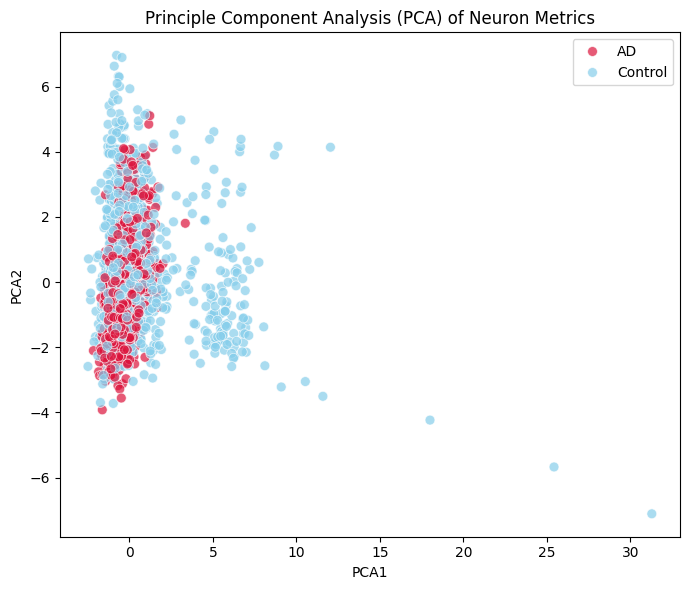

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

X_no_outliers = filtered_no_outliers_balanced[features]
X_no_outliers_scaled = scaler.fit_transform(X_no_outliers)

filtered_no_outliers_balanced = filtered_no_outliers_balanced.copy()
filtered_no_outliers_balanced.loc[:, 'label_str'] = filtered_no_outliers_balanced['label'].map({0: 'Control', 1: 'AD'})

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_no_outliers_scaled)

filtered_no_outliers_balanced.loc[:, 'PCA1'] = pca_result[:, 0]
filtered_no_outliers_balanced.loc[:, 'PCA2'] = pca_result[:, 1]


plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=filtered_no_outliers_balanced,
    x='PCA1', y='PCA2',
    hue='label_str',
    palette={'Control': 'skyblue', 'AD': 'crimson'},
    alpha=0.7,
    s=50
)
plt.title('Principle Component Analysis (PCA) of Neuron Metrics')
plt.legend(fontsize=10, title_fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
feature_names = X.columns

loadings = pd.DataFrame(pca.components_.T,
                        columns=['PCA1', 'PCA2'],
                        index=feature_names)

top_pca1 = loadings['PCA1'].abs().sort_values(ascending=False).head(3)
top_pca2 = loadings['PCA2'].abs().sort_values(ascending=False).head(3)

print("Top 3 features contributing to PCA1:")
print(top_pca1)

print("\nTop 3 features contributing to PCA2:")
print(top_pca2)

Top 3 features contributing to PCA1:
soma_surface_area    0.476526
soma_radius          0.439365
soma_volume          0.406495
Name: PCA1, dtype: float64

Top 3 features contributing to PCA2:
n_bifs                0.533395
number_of_sections    0.531362
number_of_segments    0.524832
Name: PCA2, dtype: float64


In [ ]:
top_features = list(set(top_pca1.index) | set(top_pca2.index))
X_kmeans = filtered_no_outliers_balanced[top_features]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans)

In [ ]:
from sklearn.cluster import KMeans

k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_kmeans_scaled)

filtered_no_outliers_balanced['cluster'] = clusters

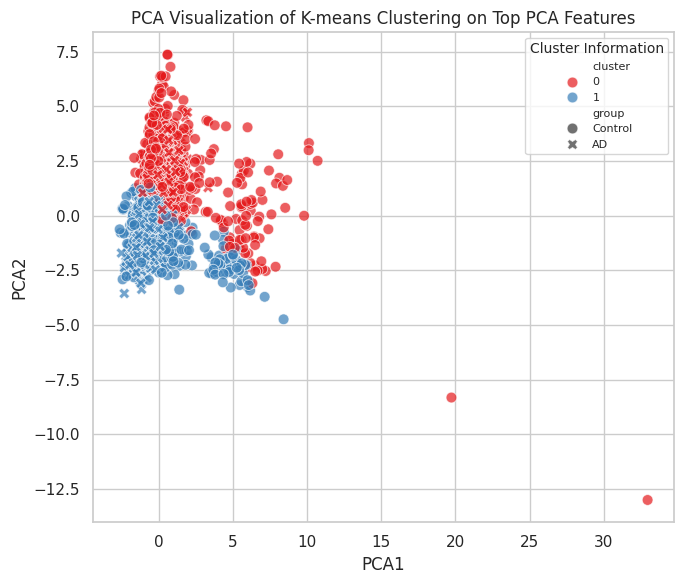

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=pca_result[:, 0], y=pca_result[:, 1],
    hue=filtered_no_outliers_balanced['cluster'].astype(str),
    palette='Set1',
    style=filtered_no_outliers_balanced['group'],
    s=60,
    alpha=0.7
)
plt.title('PCA Visualization of K-means Clustering on Top PCA Features')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Cluster Information', fontsize=8,title_fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_kmeans_scaled, clusters)
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.429


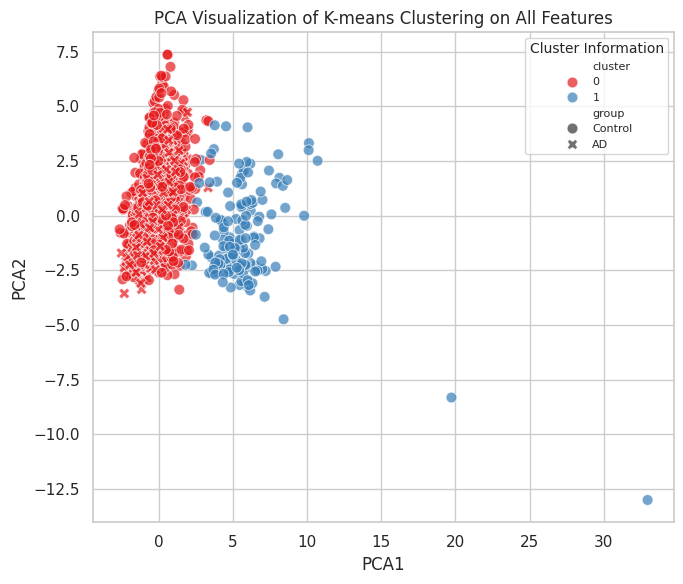

In [ ]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_no_outliers_scaled)

filtered_no_outliers_balanced['cluster'] = clusters

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_no_outliers_scaled)

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=pca_result[:, 0], y=pca_result[:, 1],
    hue=filtered_no_outliers_balanced['cluster'].astype(str),
    palette='Set1',
    style=filtered_no_outliers_balanced['group'],
    s=60,
    alpha=0.7
)
plt.title('PCA Visualization of K-means Clustering on All Features')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Cluster Information', fontsize=8,title_fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
score = silhouette_score(X_no_outliers_scaled, clusters)
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.572


In [ ]:
def load_metadata_from_folder(folder_path, group_label):
    all_metadata = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".csv"):
            neuron_name = filename.replace(".csv", "")
            file_path = os.path.join(folder_path, filename)
            df2 = pd.read_csv(file_path)
            df2["neuron_name"] = neuron_name
            df2["group"] = group_label
            all_metadata.append(df2)
    return pd.concat(all_metadata, ignore_index=True)

ad_folder = "/content/ASSIP_Full_AD_Metadata/ASSIP_Full_AD_Metadata"
ctrl_folder = "/content/ASSIP_Full_Control_Metadata/ASSIP_Full_Control_Metadata"

ad_metadata = load_metadata_from_folder(ad_folder, group_label="AD")
ctrl_metadata = load_metadata_from_folder(ctrl_folder, group_label="Control")

print(ad_metadata.head())
print(ctrl_metadata.head())


                           _links_measurements_href  \
0  http://neuromorpho.org/api/morphometry/id/238649   
1  http://neuromorpho.org/api/morphometry/id/226075   
2  http://neuromorpho.org/api/morphometry/id/216281   
3  http://neuromorpho.org/api/morphometry/id/229888   
4  http://neuromorpho.org/api/morphometry/id/204455   

              _links_persistence_vector_href  \
0  http://neuromorpho.org/api/pvec/id/238649   
1  http://neuromorpho.org/api/pvec/id/226075   
2  http://neuromorpho.org/api/pvec/id/216281   
3  http://neuromorpho.org/api/pvec/id/229888   
4  http://neuromorpho.org/api/pvec/id/204455   

                              _links_self_href age_classification age_scale  \
0  http://neuromorpho.org/api/neuron/id/238649              adult     Month   
1  http://neuromorpho.org/api/neuron/id/226075              adult     Month   
2  http://neuromorpho.org/api/neuron/id/216281              adult     Month   
3  http://neuromorpho.org/api/neuron/id/229888              adul

In [ ]:
combined_metadata = pd.concat([ad_metadata, ctrl_metadata], ignore_index=True)

In [ ]:
combined_metadata.head()

,_links_measurements_href,_links_persistence_vector_href,_links_self_href,age_classification,age_scale,archive,attributes,brain_region,cell_type,corrected_value,...,scientific_name,shrinkage_corrected,shrinkage_reported,slicing_direction,slicing_thickness,species,stain,strain,upload_date,group
0,http://neuromorpho.org/api/morphometry/id/238649,http://neuromorpho.org/api/pvec/id/238649,http://neuromorpho.org/api/neuron/id/238649,adult,Month,Siegert,"No Diameter, 3D, Angles","['hippocampus', 'dentate gyrus']","['Glia', 'microglia', 'Iba1-positive']",NaN,...,NaN,NaN,Not reported,coronal,100,mouse,immunostaining,"B6SJL-Tg(APPSwFlLon,PSEN1*M146L*L286V)6799Vas/...",2022-09-22,AD
1,http://neuromorpho.org/api/morphometry/id/226075,http://neuromorpho.org/api/pvec/id/226075,http://neuromorpho.org/api/neuron/id/226075,adult,Month,Siegert,"No Diameter, 3D, Angles","['hippocampus', 'dentate gyrus']","['Glia', 'microglia', 'Iba1-positive']",NaN,...,NaN,NaN,Not reported,coronal,100,mouse,immunostaining,"B6SJL-Tg(APPSwFlLon,PSEN1*M146L*L286V)6799Vas/...",2022-09-22,AD
2,http://neuromorpho.org/api/morphometry/id/216281,http://neuromorpho.org/api/pvec/id/216281,http://neuromorpho.org/api/neuron/id/216281,adult,Month,Siegert,"No Diameter, 3D, Angles","['hippocampus', 'dentate gyrus']","['Glia', 'microglia', 'Iba1-positive']",NaN,...,NaN,NaN,Not reported,coronal,100,mouse,immunostaining,"B6SJL-Tg(APPSwFlLon,PSEN1*M146L*L286V)6799Vas/...",2022-09-22,AD
3,http://neuromorpho.org/api/morphometry/id/229888,http://neuromorpho.org/api/pvec/id/229888,http://neuromorpho.org/api/neuron/id/229888,adult,Month,Siegert,"No Diameter, 3D, Angles","['hippocampus', 'dentate gyrus']","['Glia', 'microglia', 'Iba1-positive']",NaN,...,NaN,NaN,Not reported,coronal,100,mouse,immunostaining,"B6SJL-Tg(APPSwFlLon,PSEN1*M146L*L286V)6799Vas/...",2022-09-22,AD
4,http://neuromorpho.org/api/morphometry/id/204455,http://neuromorpho.org/api/pvec/id/204455,http://neuromorpho.org/api/neuron/id/204455,adult,Month,Siegert,"No Diameter, 3D, Angles","['hippocampus', 'dentate gyrus']","['Glia', 'microglia', 'Iba1-positive']",NaN,...,NaN,NaN,Not reported,coronal,100,mouse,immunostaining,"B6SJL-Tg(APPSwFlLon,PSEN1*M146L*L286V)6799Vas/...",2022-09-22,AD


In [ ]:
combined_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6035 entries, 0 to 6034
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   _links_measurements_href        6035 non-null   object 
 1   _links_persistence_vector_href  6035 non-null   object 
 2   _links_self_href                6035 non-null   object 
 3   age_classification              6035 non-null   object 
 4   age_scale                       6035 non-null   object 
 5   archive                         6035 non-null   object 
 6   attributes                      6035 non-null   object 
 7   brain_region                    6035 non-null   object 
 8   cell_type                       6035 non-null   object 
 9   corrected_value                 227 non-null    float64
 10  corrected_xy                    0 non-null      float64
 11  corrected_z                     239 non-null    float64
 12  deposition_date                 60

In [ ]:
skipped_files = [
    "Kyrargyri_Attwell_C2-12.CNG.swc",
    "Kyrargyri_Attwell_C2-28.CNG.swc",
    "3DDS_24_VK.CNG.swc",
    "Kyrargyri_Attwell_C2-5.CNG.swc",
    "Kyrargyri_Attwell_C2-11.CNG.swc",
    "3DDS_27_VK.CNG.swc",
    "3DDS_29_VK.CNG.swc",
    "3DDS_33_VK.CNG.swc",
    "Kyrargyri_Attwell_C2-23.CNG.swc",
    "Kyrargyri_Attwell_C2-13.CNG.swc",
    "3DDS_31_VK.CNG.swc",
    "Kyrargyri_Attwell_C2-25.CNG.swc",
    "Kyrargyri_Attwell_C2-3.CNG.swc",
    "3DDS_17_VK.CNG.swc",
    "3DDS_28_VK.CNG.swc",
    "3DDS_6_VK.CNG.swc",
    "3DDS_13_VK.CNG.swc",
    "Kyrargyri_Attwell_C2-4.CNG.swc",
    "Kyrargyri_Attwell_C2-7.CNG.swc",
    "Kyrargyri_Attwell_C2-10.CNG.swc",
    "3DDS_15_VK.CNG.swc",
    "3DDS_22_VK.CNG.swc",
    "3DDS_20_VK.CNG.swc",
    "3DDS_14_VK.CNG.swc",
    "3DDS_25_VK.CNG.swc"
]

In [ ]:
combined_metadata['neuron_name'] = combined_metadata['neuron_name'].str.replace('_metadata$', '.swc', regex=True)

skipped_files_cleaned = [name.replace('.CNG', '') for name in skipped_files]

filtered_metadata = combined_metadata[~combined_metadata['neuron_name'].isin(skipped_files_cleaned)].copy()

print(f"Before filtering: {combined_metadata.shape}")
print(f"After filtering: {filtered_metadata.shape}")

Before filtering: (6035, 45)
After filtering: (6010, 45)


In [ ]:
for file in skipped_files_cleaned:
    filtered_data = combined_metadata[combined_metadata['neuron_name'] == file]
    print(filtered_data[['age_classification', 'gender']])


     age_classification       gender
1707              adult  Male/Female
     age_classification       gender
1968              adult  Male/Female
     age_classification       gender
4519              adult  Male/Female
     age_classification       gender
4843              adult  Male/Female
     age_classification       gender
1866              adult  Male/Female
     age_classification       gender
1836              adult  Male/Female
     age_classification       gender
1446              adult  Male/Female
     age_classification       gender
1501              adult  Male/Female
     age_classification       gender
2347              adult  Male/Female
     age_classification       gender
4255              adult  Male/Female
     age_classification       gender
3387              adult  Male/Female
     age_classification       gender
1479              adult  Male/Female
     age_classification       gender
3233              adult  Male/Female
     age_classification       gender
4

In [ ]:
filtered_metadata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6010 entries, 0 to 6034
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   _links_measurements_href        6010 non-null   object 
 1   _links_persistence_vector_href  6010 non-null   object 
 2   _links_self_href                6010 non-null   object 
 3   age_classification              6010 non-null   object 
 4   age_scale                       6010 non-null   object 
 5   archive                         6010 non-null   object 
 6   attributes                      6010 non-null   object 
 7   brain_region                    6010 non-null   object 
 8   cell_type                       6010 non-null   object 
 9   corrected_value                 227 non-null    float64
 10  corrected_xy                    0 non-null      float64
 11  corrected_z                     239 non-null    float64
 12  deposition_date                 6010 no

In [ ]:
# 1. Ensure 'df' actually has the column (it might be named 'neuron_name' or 'Unnamed: 0')
if 'neuron_name' not in df.columns:
    # If the first column is the names, rename it
    df.rename(columns={df.columns[0]: 'neuron_name'}, inplace=True)

# 2. Clean the extensions so they match the metadata
df['neuron_name'] = df['neuron_name'].str.replace('.CNG.swc', '.swc', regex=False)
df['neuron_name'] = df['neuron_name'].str.replace('_metadata', '.swc', regex=False)

# 3. Now perform the merge
merged_df = df.merge(filtered_metadata_clean, on='neuron_name')

In [ ]:
df['neuron_name']

,neuron_name
0,AD
1,AD
2,AD
3,AD
4,AD
...,...
6005,Control
6006,Control
6007,Control
6008,Control


In [ ]:
filtered_metadata['neuron_name']

,neuron_name
0,DG_5xFAD_3mpos_F_Animal01_Trace128.swc
1,DG_5xFAD_3mpos_M_Animal03_Trace100.swc
2,DG_5xFAD_3mpos_F_Animal02_Trace039.swc
3,DG_5xFAD_3mpos_M_Animal02_Trace002.swc
4,DG_5xFAD_6mpos_M_Animal01_Trace043.swc
...,...
6030,AP7_SEA_Middle-thirds_DG-Mol_sec4-cel1-apv7mm.swc
6031,DG_Adulthood_Control_F_Animal01_Trace655.swc
6032,DG_Adulthood_Control_M_Animal01_Trace329.swc
6033,IBA1_Ctrl_2c.swc


In [ ]:
filtered_metadata_clean = filtered_metadata.dropna(axis=1, how='any')

In [ ]:
filtered_metadata_clean.shape

(6010, 35)

In [ ]:
df['neuron_name'] = df['neuron_name'].str.replace('.CNG.swc', '.swc', regex=False)

In [ ]:
df.to_excel('/content/drive/MyDrive/ASSIP_2025/Neuron_Metrics_Report_725.xlsx', index=False)

OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/ASSIP_2025'

In [ ]:
print("Example from Morphometry (df):", list(df['neuron_name'])[:5])
print("Example from Metadata (filtered_metadata_clean):", list(filtered_metadata_clean['neuron_name'])[:5])

Example from Morphometry (df): ['AD', 'AD', 'AD', 'AD', 'AD']
Example from Metadata (filtered_metadata_clean): ['DG_5xFAD_3mpos_F_Animal01_Trace128.swc', 'DG_5xFAD_3mpos_M_Animal03_Trace100.swc', 'DG_5xFAD_3mpos_F_Animal02_Trace039.swc', 'DG_5xFAD_3mpos_M_Animal02_Trace002.swc', 'DG_5xFAD_6mpos_M_Animal01_Trace043.swc']


In [ ]:
# Check the current columns to find where the real names are
print("Current columns in df:", df.columns.tolist())

# If the real names are in the index, move them to 'neuron_name'
df['neuron_name'] = df.index

# If the output still shows 'AD', we need to check the first column:
# df['neuron_name'] = df.iloc[:, 0]

# Now strip the extensions as we planned
df['neuron_name_base'] = (df['neuron_name']
                          .astype(str)
                          .str.replace('.CNG.swc', '', regex=False)
                          .str.replace('.swc', '', regex=False)
                          .str.strip())

Current columns in df: ['neuron_name', 'gender', 'n_bifs']


In [ ]:
filtered_metadata_clean['neuron_name_base'] = (filtered_metadata_clean['neuron_name']
                                               .astype(str)
                                               .str.replace('.swc', '', regex=False)
                                               .str.replace('_metadata', '', regex=False)
                                               .str.strip())

# Test the match again
shared = set(df['neuron_name_base']).intersection(set(filtered_metadata_clean['neuron_name_base']))
print(f"Shared names found: {len(shared)}")

Shared names found: 0


/tmp/ipykernel_944/3191730923.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_metadata_clean['neuron_name_base'] = (filtered_metadata_clean['neuron_name']


In [ ]:
# 1. Merge the datasets
merged_df = df.merge(filtered_metadata_clean, on='neuron_name_base')

# 2. CREATE THE MASTER ADULT COHORT
# This ensures a scientifically valid comparison for your paper
adult_df = merged_df[merged_df['age_classification'] == 'adult'].copy()

# 3. Clean gender for sex-stratified analysis (RQ2)
adult_df = adult_df[adult_df['gender'].isin(['Male', 'Female'])]

print("Final Adult-Only Population per Group:")
print(adult_df.groupby(['group', 'gender']).size())

KeyError: 'gender'

In [ ]:
df_names = set(df['neuron_name'])
meta_names = set(filtered_metadata_clean['neuron_name'])

shared_names = df_names.intersection(meta_names)

print(f"Shared neuron_name values after fix: {len(shared_names)}")  # should be 6010


Shared neuron_name values after fix: 0


In [ ]:
merged_df = df.merge(filtered_metadata_clean, on='neuron_name')
print("Merged shape:", merged_df.shape)
filtered_metadata_clean = filtered_metadata_clean.dropna(axis=1)
are_groups_equal = (merged_df['group_x'] == merged_df['group_y']).all()
print("Are group_x and group_y the same?", are_groups_equal)




Merged shape: (6010, 46)
Are group_x and group_y the same? True


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6010 entries, 0 to 6009
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neuron_name                     6010 non-null   object 
 1   group_x                         6010 non-null   object 
 2   soma_volume                     6010 non-null   float64
 3   soma_surface_area               6010 non-null   float64
 4   soma_radius                     6010 non-null   float64
 5   number_of_neurites              6010 non-null   int64  
 6   number_of_sections              6010 non-null   int64  
 7   number_of_segments              6010 non-null   int64  
 8   mean_section_length             6010 non-null   float64
 9   mean_segment_length             6010 non-null   float64
 10  mean_local_bif_angle            6010 non-null   float64
 11  n_bifs                          6010 non-null   int64  
 12  _links_measurements_href        60

In [ ]:
# Check if the two group columns are exactly the same
are_groups_equal = (merged_df['group_x'] == merged_df['group_y']).all()
print("Are group_x and group_y the same?", are_groups_equal)


KeyError: 'group_x'

In [ ]:
if are_groups_equal:
    merged_df = merged_df.drop(columns='group_y')
    merged_df = merged_df.rename(columns={'group_x': 'group'})
else:
    print("Warning: group_x and group_y differ! Investigate before dropping.")


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6010 entries, 0 to 6009
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neuron_name                     6010 non-null   object 
 1   group                           6010 non-null   object 
 2   soma_volume                     6010 non-null   float64
 3   soma_surface_area               6010 non-null   float64
 4   soma_radius                     6010 non-null   float64
 5   number_of_neurites              6010 non-null   int64  
 6   number_of_sections              6010 non-null   int64  
 7   number_of_segments              6010 non-null   int64  
 8   mean_section_length             6010 non-null   float64
 9   mean_segment_length             6010 non-null   float64
 10  mean_local_bif_angle            6010 non-null   float64
 11  n_bifs                          6010 non-null   int64  
 12  _links_measurements_href        60

In [ ]:
merged_df.to_excel('/content/drive/MyDrive/ASSIP_2025/Neuron_morphology_report_with_metadata_729.xlsx', index=False)

OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/ASSIP_2025'

In [ ]:
merged_df['age_classification'].value_counts()

,count
age_classification,
adult,4135
young adult,1104
old,404
young,367


In [ ]:
print("Samples per age_classification:")
print(merged_df['age_classification'].value_counts(), "\n")

print("Samples per age_classification per group:")
print(merged_df.groupby(['group', 'age_classification']).size(), "\n")

print("Samples per gender:")
print(merged_df['gender'].value_counts(), "\n")

print("Samples per gender per group:")
print(merged_df.groupby(['group', 'gender']).size(), "\n")

print("Cross-tabulation age_classification × gender:")
print(pd.crosstab(merged_df['age_classification'], merged_df['gender']), "\n")

print("Cross-tabulation age_classification × gender per group:")
print(pd.crosstab(merged_df['age_classification'], merged_df['gender'], margins=True))
print(merged_df.groupby(['group']).apply(lambda x: pd.crosstab(x['age_classification'], x['gender'])))


Samples per age_classification:
age_classification
adult          4135
young adult    1104
old             404
young           367
Name: count, dtype: int64 

Samples per age_classification per group:
group    age_classification
AD       adult                 1176
Control  adult                 2959
         old                    404
         young                  367
         young adult           1104
dtype: int64 

Samples per gender:
gender
Female         3180
Male           2513
Male/Female     317
Name: count, dtype: int64 

Samples per gender per group:
group    gender     
AD       Female          657
         Male            519
Control  Female         2523
         Male           1994
         Male/Female     317
dtype: int64 

Cross-tabulation age_classification × gender:
gender              Female  Male  Male/Female
age_classification                           
adult                 2070  1748          317
old                    367    37            0
young               

/tmp/ipykernel_944/743553963.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(merged_df.groupby(['group']).apply(lambda x: pd.crosstab(x['age_classification'], x['gender'])))


In [ ]:
# Create the Master Adult Cohort
# This filters out 'young', 'young adult', and 'old' from the Controls
# because the AD group only contains 'adult'
adult_df = filtered_df[filtered_df['age_classification'] == 'adult'].copy()

# Also remove the 'Male/Female' ambiguous category for sex-stratified analysis
adult_df = adult_df[adult_df['gender'].isin(['Male', 'Female'])]

print(f"Original samples: {len(filtered_df)}")
print(f"Adult-matched samples: {len(adult_df)}")
print(adult_df.groupby(['group', 'gender']).size())

Original samples: 5452
Adult-matched samples: 3620
group    gender
AD       Female     656
         Male       516
Control  Female    1360
         Male      1088
dtype: int64


In [ ]:
metrics = ['soma_volume', 'soma_surface_area', 'soma_radius',
           'number_of_neurites', 'number_of_sections', 'number_of_segments',
           'mean_section_length', 'mean_segment_length', 'mean_local_bif_angle', 'n_bifs']

In [ ]:
z_scores3 = merged_df[metrics].apply(zscore)

merged_df_no_outliers = merged_df[(z_scores3.abs() <= 3).all(axis=1)]

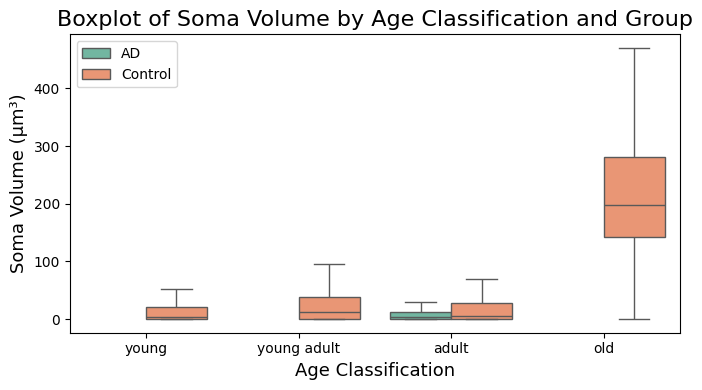

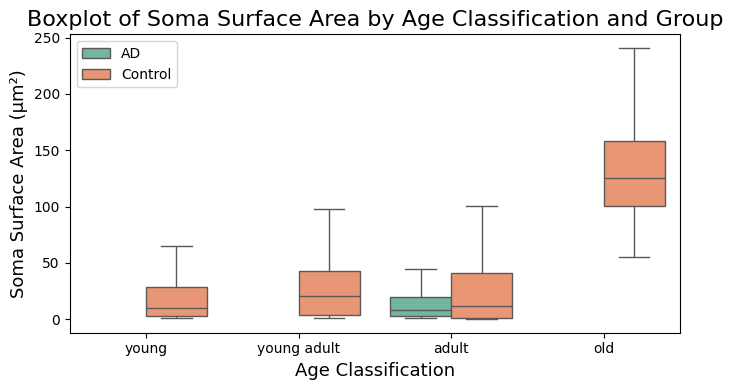

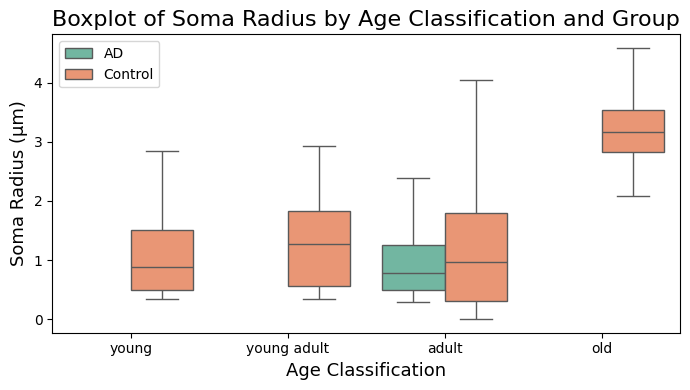

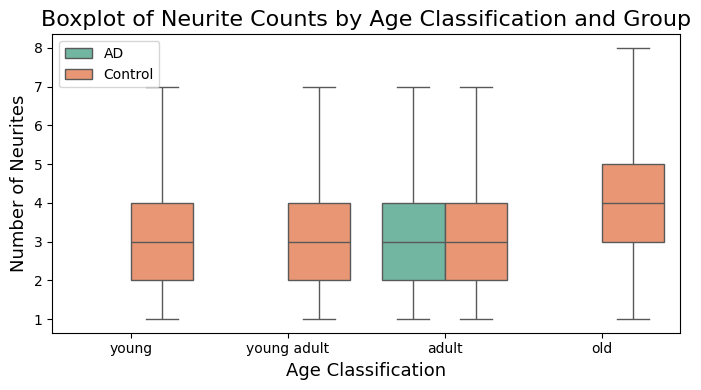

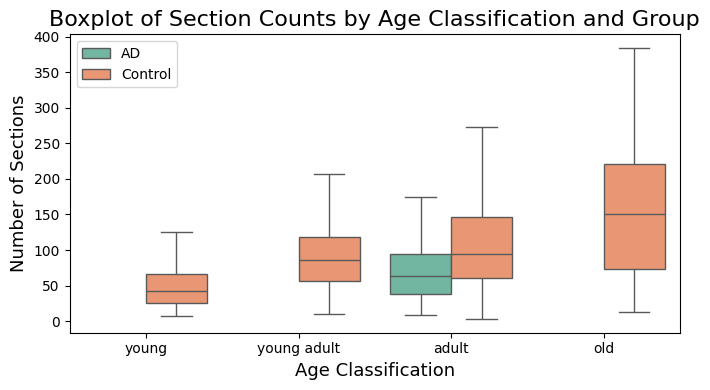

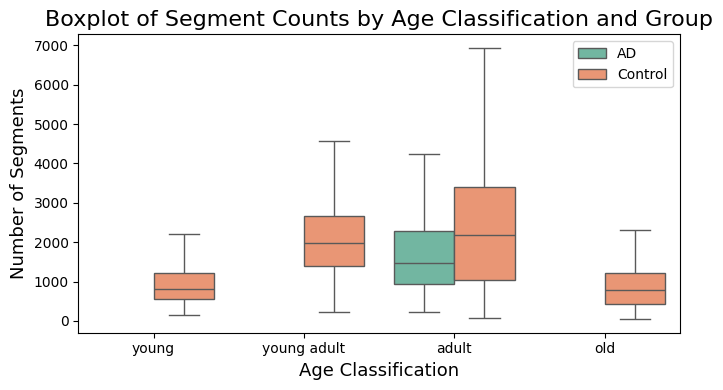

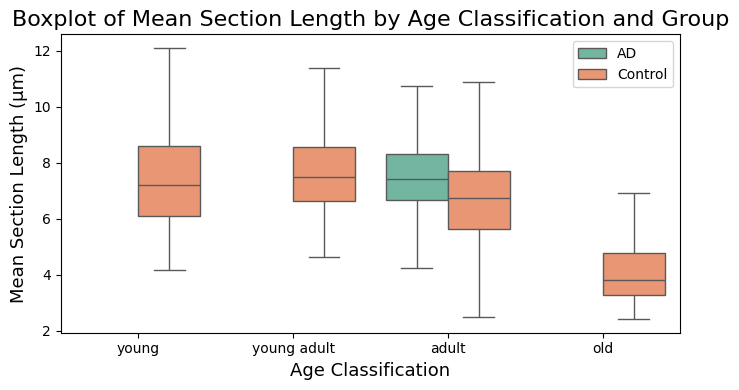

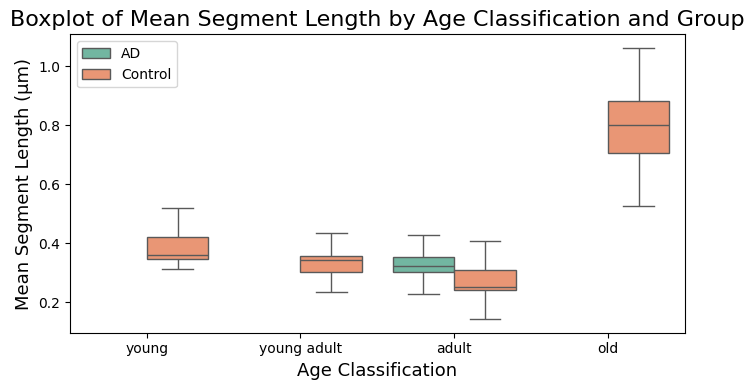

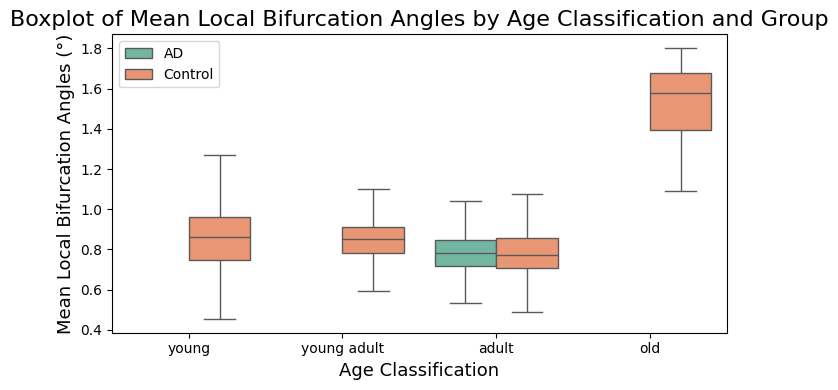

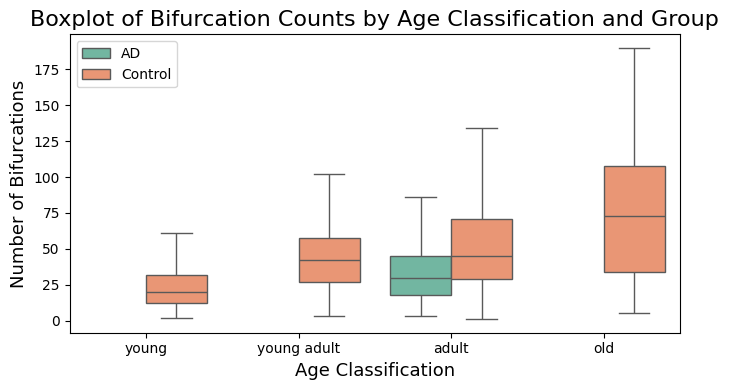

In [ ]:
age_order = ['young', 'young adult', 'adult', 'old']

def make_singular(word):
    if word.endswith('s'):
        return word[:-1]
    return word

metric_units = {
    'soma_volume': 'µm³',
    'soma_surface_area': 'µm²',
    'soma_radius': 'µm',
    'number_of_neurites': None,
    'number_of_sections': None,
    'number_of_segments': None,
    'mean_section_length': 'µm',
    'mean_segment_length': 'µm',
    'mean_local_bif_angle': '°',
    'n_bifs': None
}

for metric in metrics:
    plt.figure(figsize=(7, 4))

    sns.boxplot(data=merged_df_no_outliers, x='age_classification', y=metric, hue='group',
                order=age_order, showfliers=False, palette='Set2')

    unit = metric_units.get(metric, 'Unit')

    if 'number_of_' in metric:
        metric_name = metric.replace("number_of_", "").replace("_", " ").title()
        singular_metric_name = make_singular(metric_name.split(" ")[-1])  # Remove 's' if plural
        title = f'Boxplot of {singular_metric_name} Counts by Age Classification and Group'
        y_label = f'Number of {metric_name}'
    elif 'mean_local_bif_angle' == metric:
        title = f'Boxplot of Mean Local Bifurcation Angles by Age Classification and Group'
        y_label = f'Mean Local Bifurcation Angles ({unit})'
    elif 'n_bifs' == metric:
        title = f'Boxplot of Bifurcation Counts by Age Classification and Group'
        y_label = f'Number of Bifurcations'
    else:
        title = f'Boxplot of {metric.replace("_", " ").title()} by Age Classification and Group'
        if unit is None:
            y_label = f'{metric.replace("_", " ").title()}'
        else:
            y_label = f'{metric.replace("_", " ").title()} ({unit})'

    plt.title(title, fontsize=16)

    plt.xlabel('Age Classification', fontsize=13)
    plt.ylabel(y_label, fontsize=13)
    plt.legend(fontsize=10, title_fontsize=12)
    plt.tight_layout()


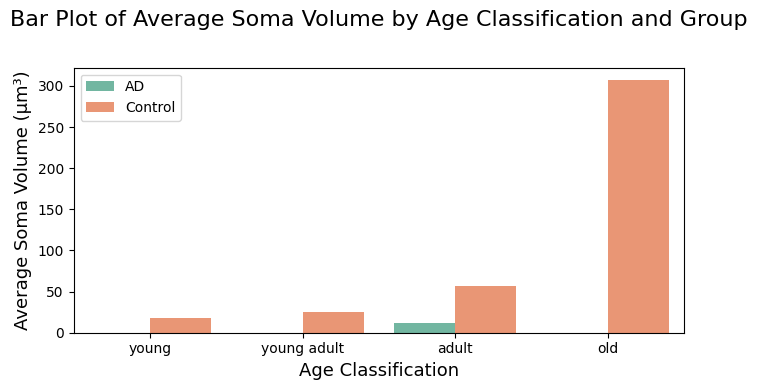

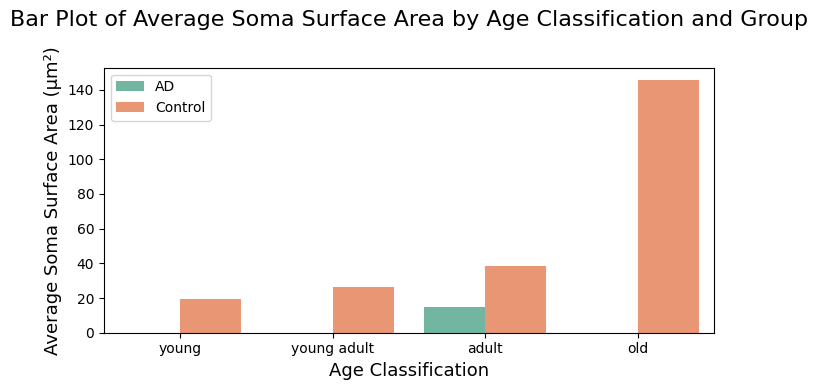

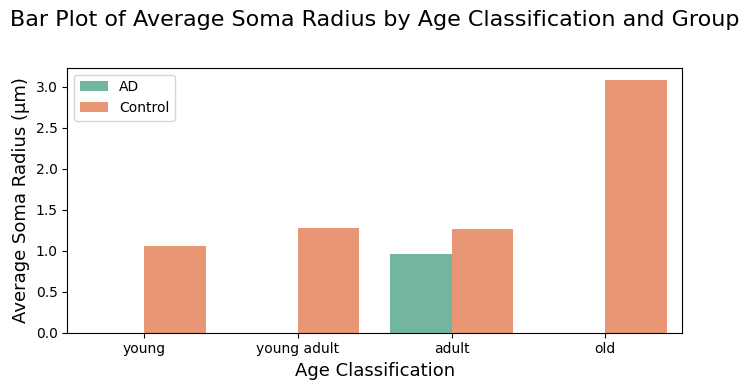

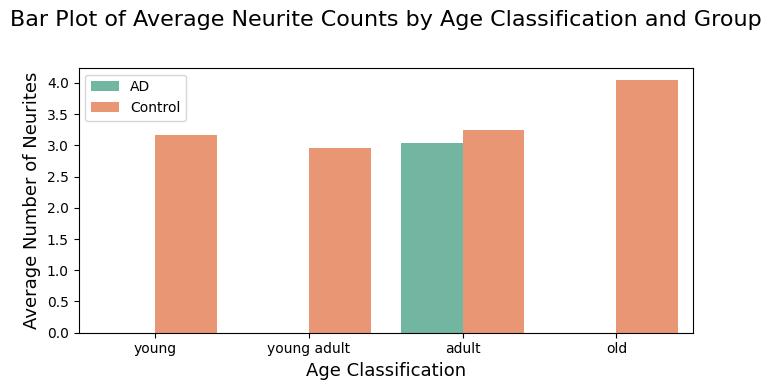

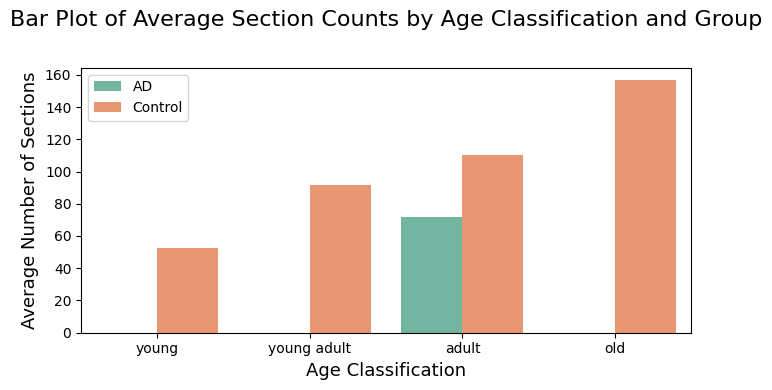

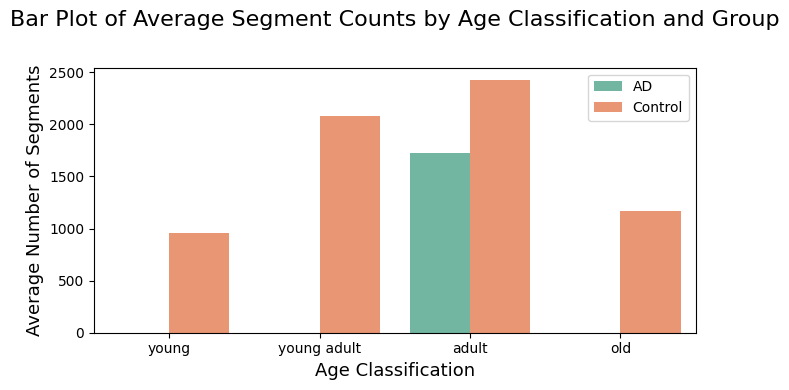

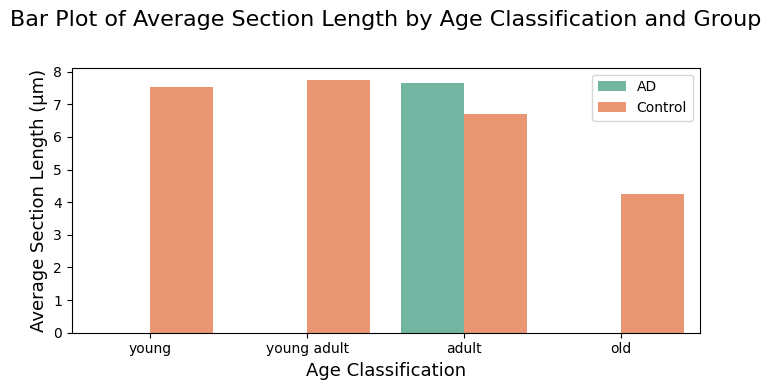

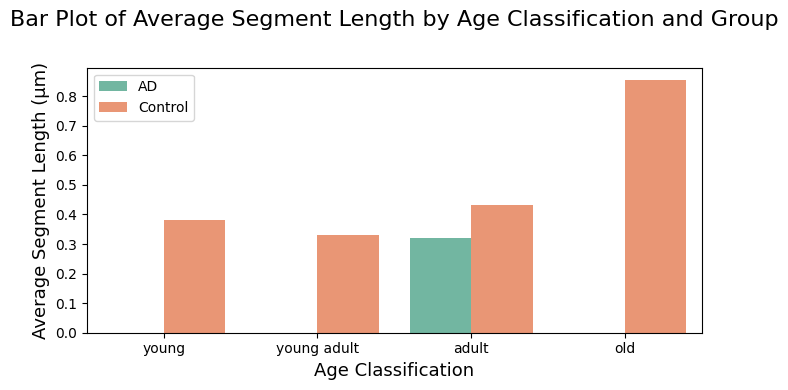

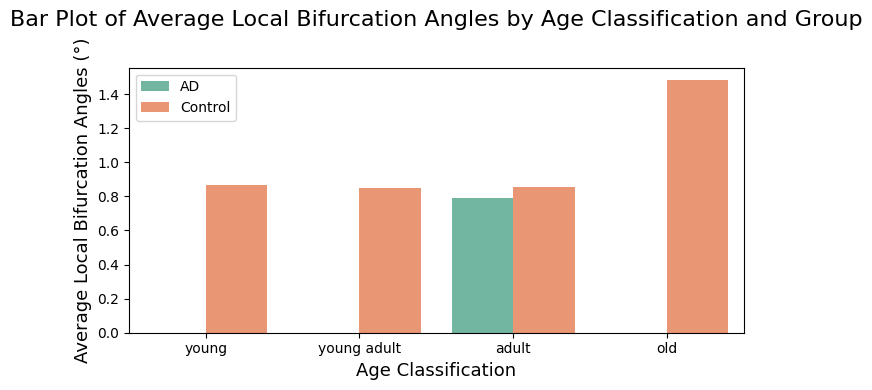

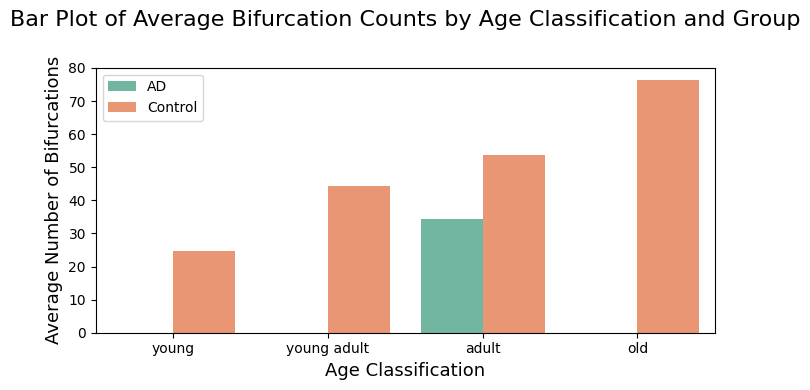

In [ ]:
age_order = ['young', 'young adult', 'adult', 'old']

for metric in metrics:
    plt.figure(figsize=(7, 4))

    avg_df = merged_df_no_outliers.groupby(['age_classification', 'group'])[metric].mean().reset_index()

    sns.barplot(data=avg_df, x='age_classification', y=metric, hue='group',
                order=age_order, palette='Set2')

    unit = metric_units.get(metric, 'Unit')

    if 'number_of_' in metric:
        metric_name = metric.replace("number_of_", "").replace("_", " ").title()
        singular_metric_name = make_singular(metric_name.split(" ")[-1])
        title = f'Bar Plot of Average {singular_metric_name} Counts by Age Classification and Group'
        y_label = f'Average Number of {metric_name}'

    elif metric == 'n_bifs':
        title = f'Bar Plot of Average Bifurcation Counts by Age Classification and Group'
        y_label = f'Average Number of Bifurcations'

    elif metric in ['mean_segment_length', 'mean_section_length']:
        metric_clean = metric.replace("mean_", "").replace("_", " ").title()
        title = f'Bar Plot of Average {metric_clean} by Age Classification and Group'
        y_label = f'Average {metric_clean}'
        if unit:
            y_label += f' ({unit})'
    elif metric == 'mean_local_bif_angle':
        title = f'Bar Plot of Average Local Bifurcation Angles by Age Classification and Group'
        y_label = f'Average Local Bifurcation Angles ({unit})'
    else:
        title = f'Bar Plot of Average {metric.replace("_", " ").title()} by Age Classification and Group'
        if unit is None:
            y_label = f'Average {metric.replace("_", " ").title()}'
        else:
            y_label = f'Average {metric.replace("_", " ").title()} ({unit})'

    plt.title(title, fontsize=16, pad=30)
    plt.xlabel('Age Classification', fontsize=13)
    plt.ylabel(y_label, fontsize=13)
    plt.legend(fontsize=10, title_fontsize=12)
    plt.tight_layout()

    plt.show()


In [ ]:
pca_metrics = ['soma_surface_area', 'mean_segment_length', 'soma_volume', 'number_of_sections', 'n_bifs', 'number_of_segments']

In [ ]:
control_meta = merged_df[merged_df['group'] == 'Control']

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

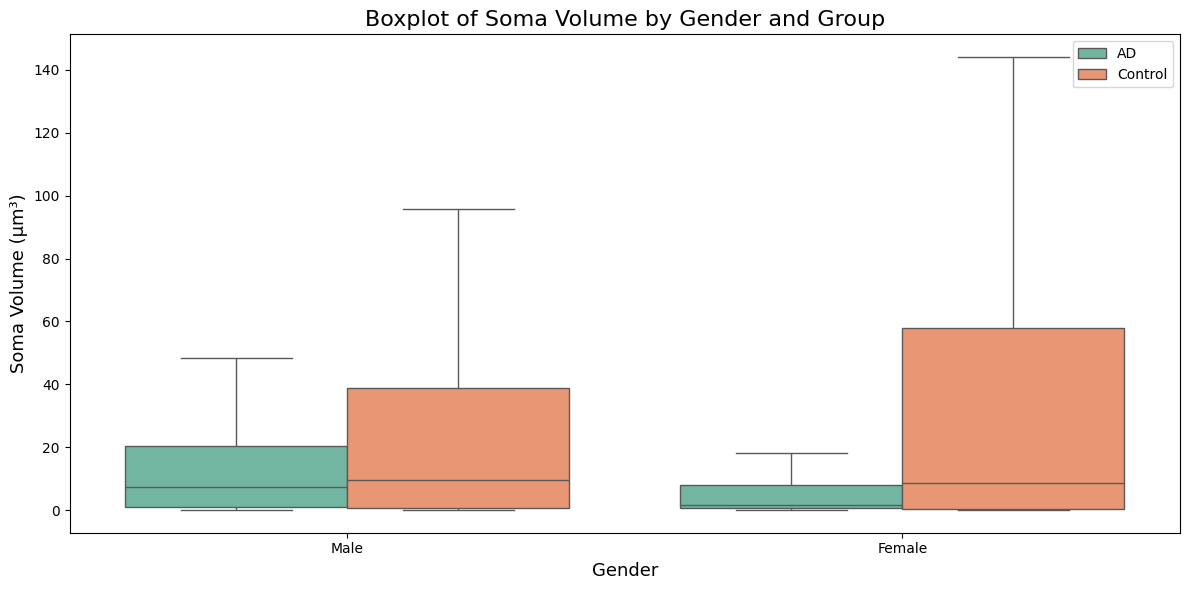

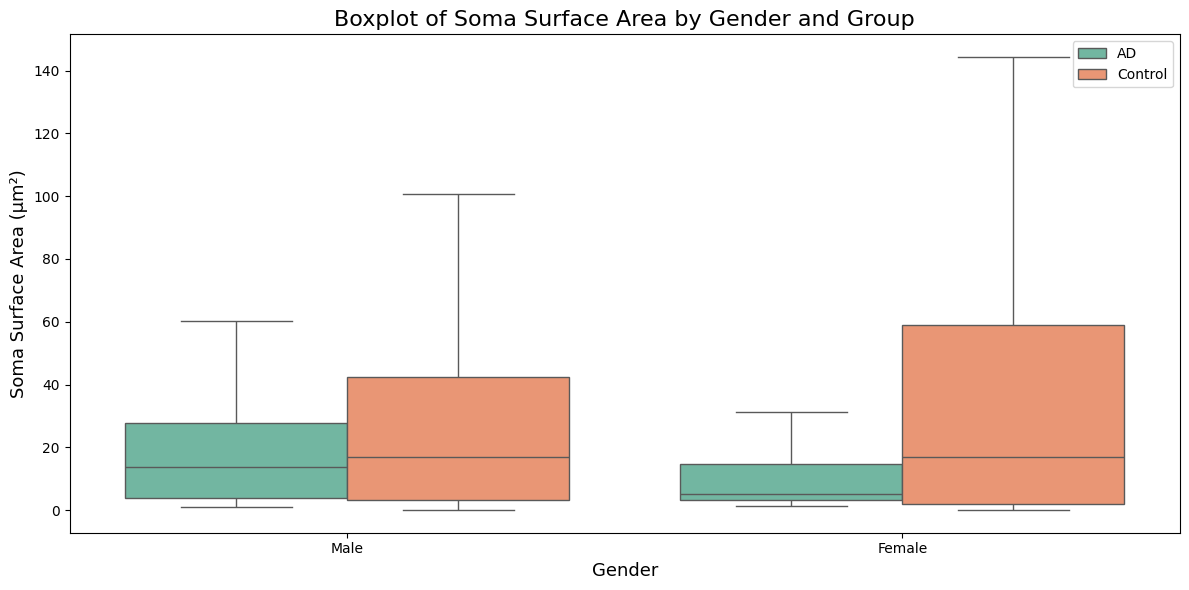

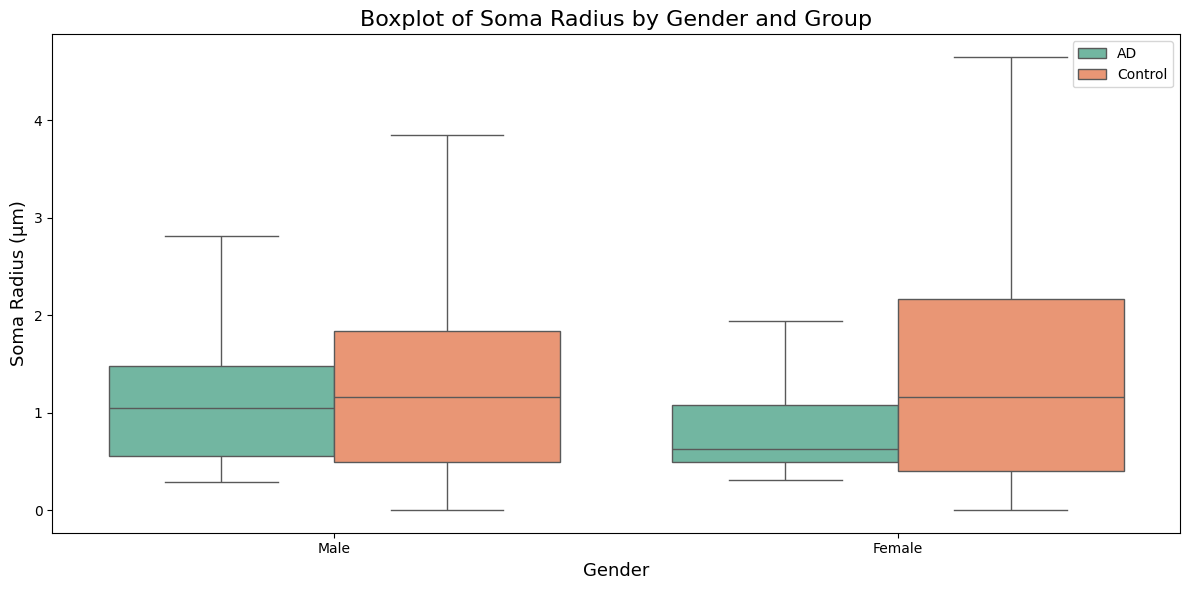

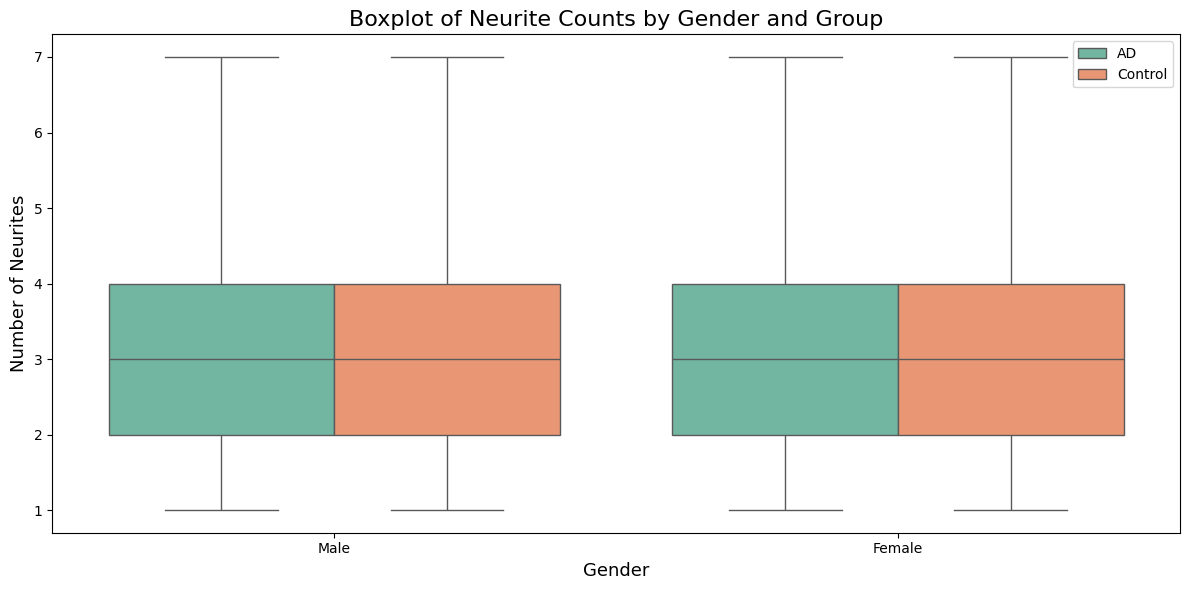

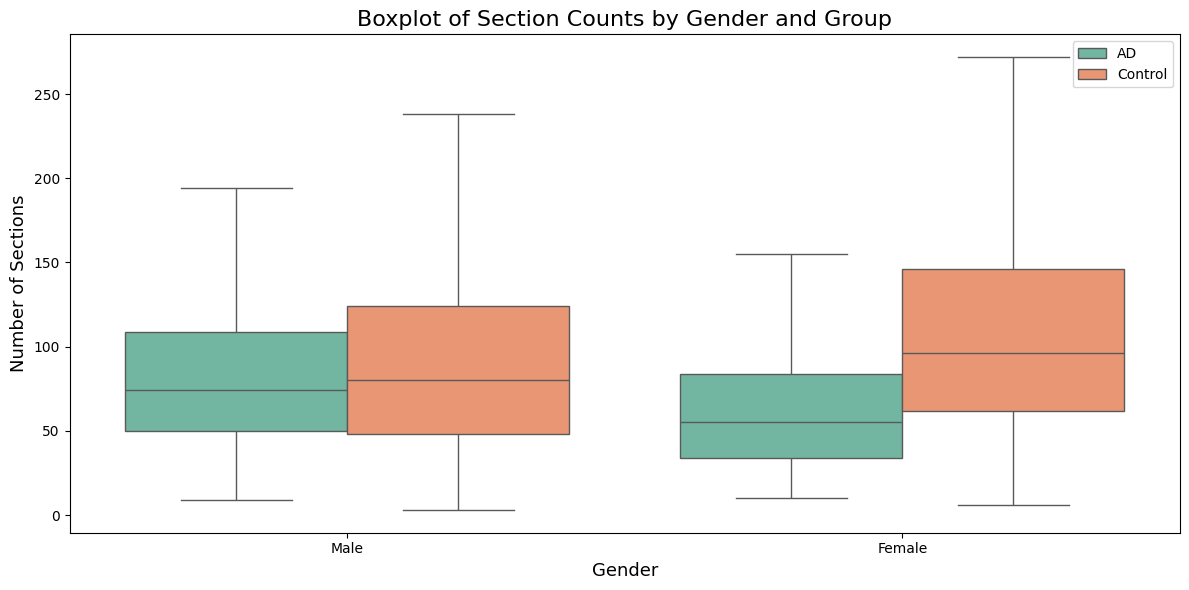

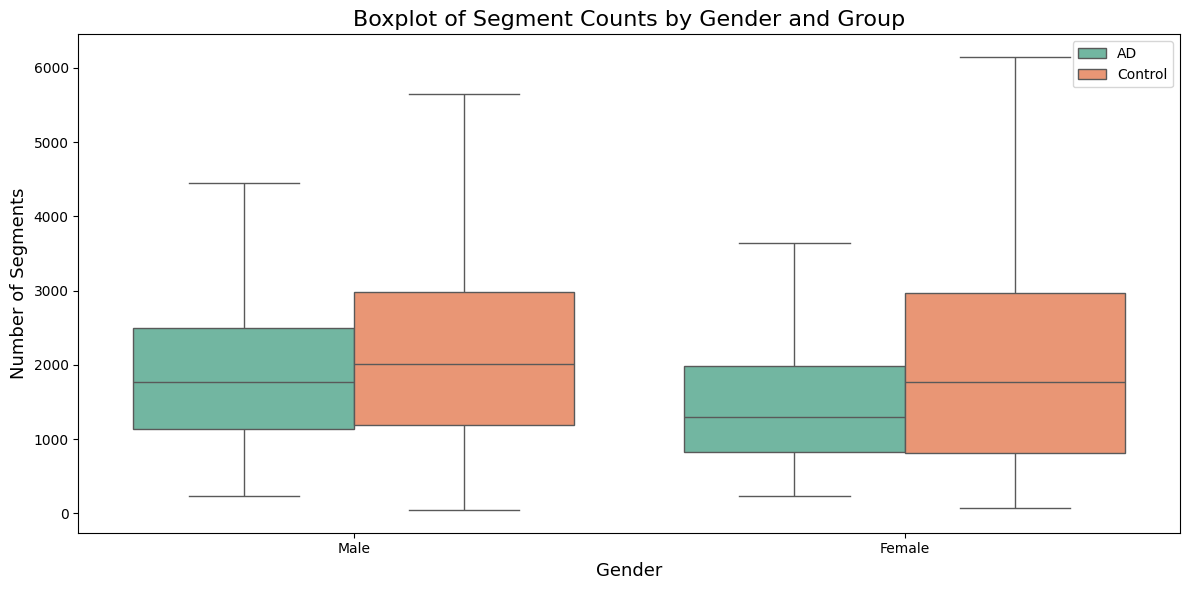

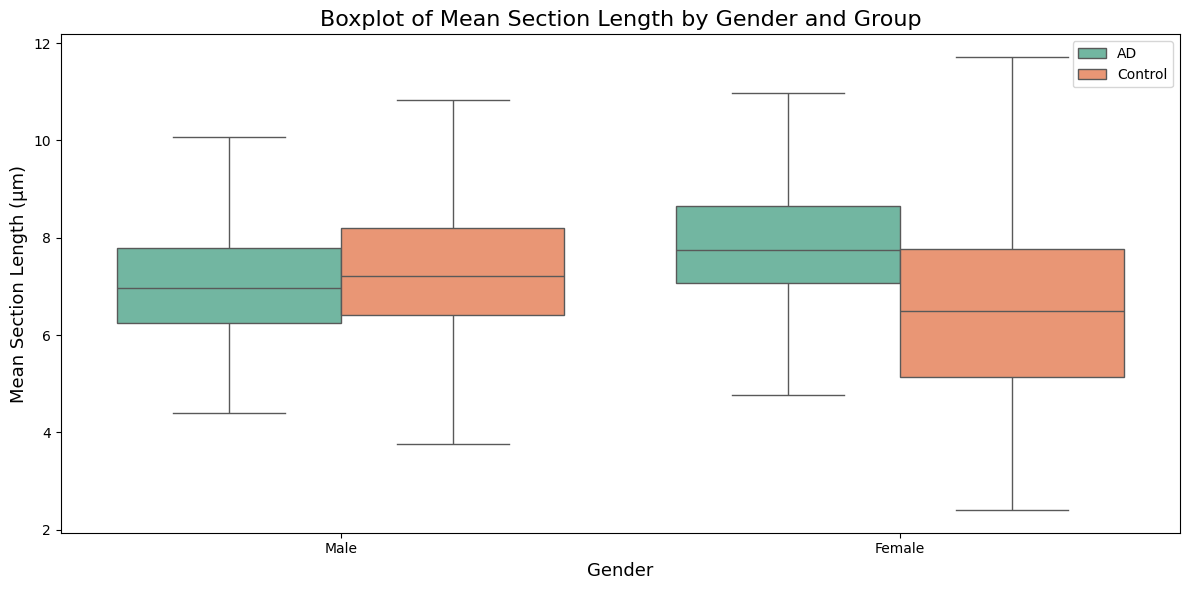

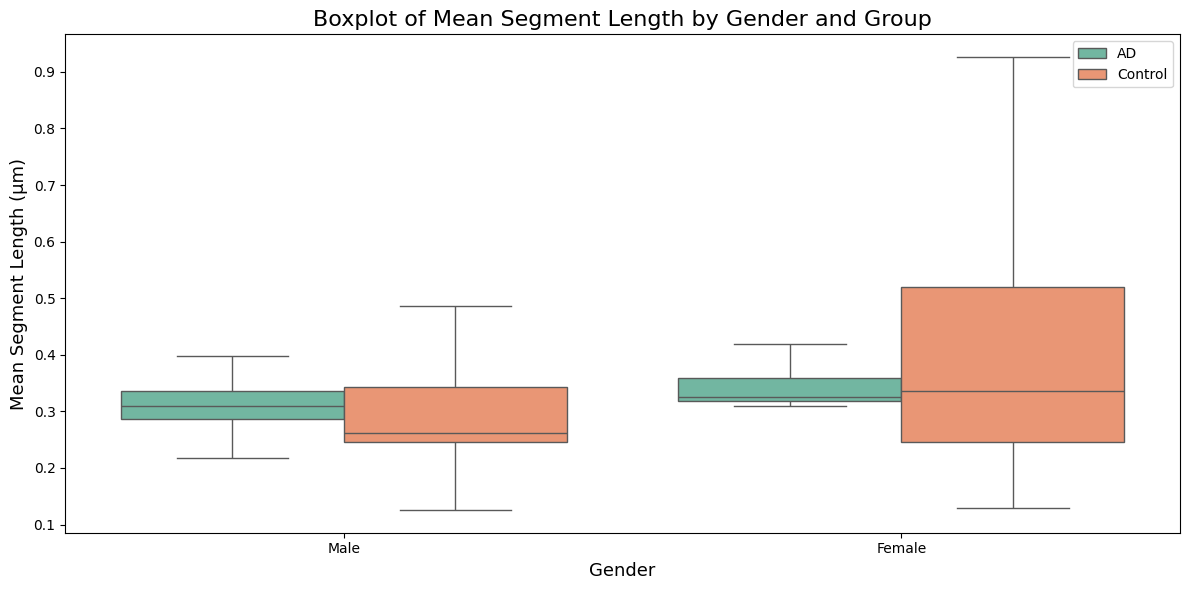

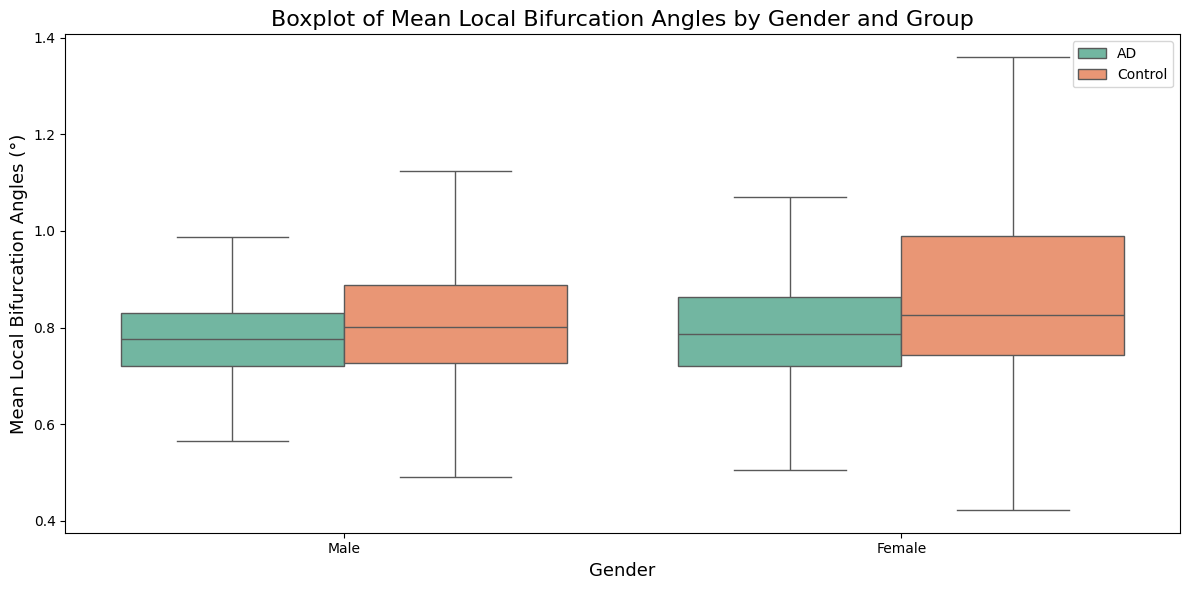

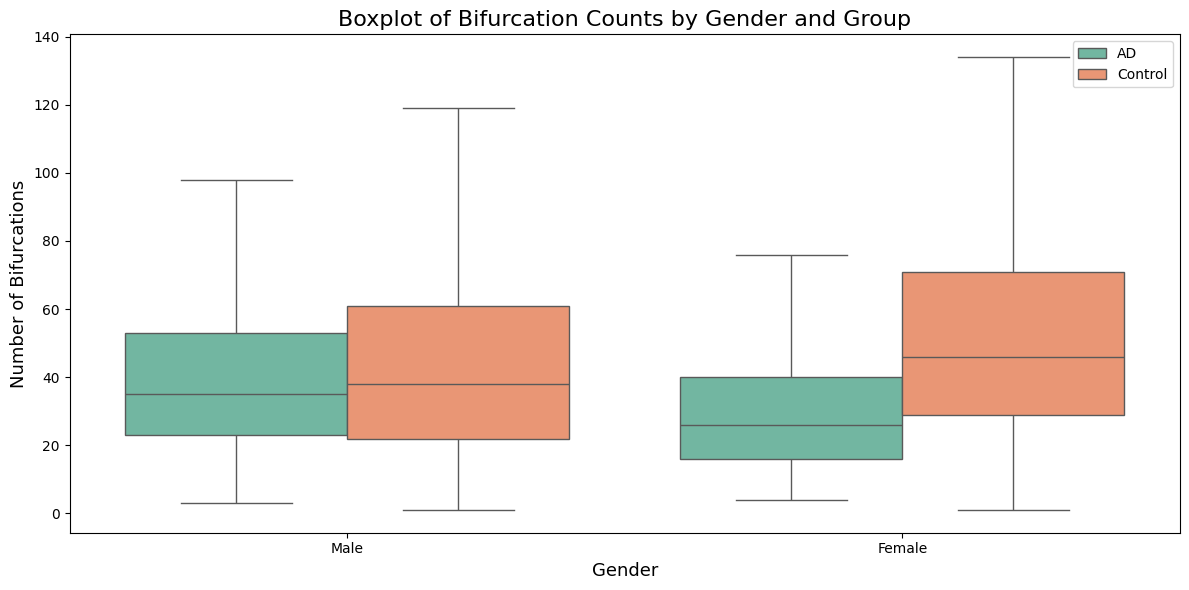

In [ ]:
filtered_df = merged_df_no_outliers[merged_df_no_outliers['gender'] != 'Male/Female']

gender_order = ['Male', 'Female']

for metric in metrics:
    plt.figure(figsize=(12, 6))

    sns.boxplot(data=filtered_df, x='gender', y=metric, hue='group', showfliers=False, order=gender_order, palette='Set2')

    unit = metric_units.get(metric, 'Unit')

    if 'number_of_' in metric:
        metric_name = metric.replace("number_of_", "").replace("_", " ").title()
        singular_metric_name = make_singular(metric_name.split(" ")[-1])
        title = f'Boxplot of {singular_metric_name} Counts by Gender and Group'
        y_label = f'Number of {metric_name}'
    elif 'mean_local_bif_angle' == metric:
        title = f'Boxplot of Mean Local Bifurcation Angles by Gender and Group'
        y_label = f'Mean Local Bifurcation Angles ({unit})'
    elif 'n_bifs' == metric:
        title = f'Boxplot of Bifurcation Counts by Gender and Group'
        y_label = f'Number of Bifurcations'
    else:
        title = f'Boxplot of {metric.replace("_", " ").title()} by Gender and Group'
        if unit is None:
            y_label = f'{metric.replace("_", " ").title()}'
        else:
            y_label = f'{metric.replace("_", " ").title()} ({unit})'

    plt.title(title, fontsize=16)
    plt.xlabel('Gender', fontsize=13)
    plt.ylabel(y_label, fontsize=13)
    plt.legend(fontsize=10, title_fontsize=12)
    plt.tight_layout()

    plt.show()

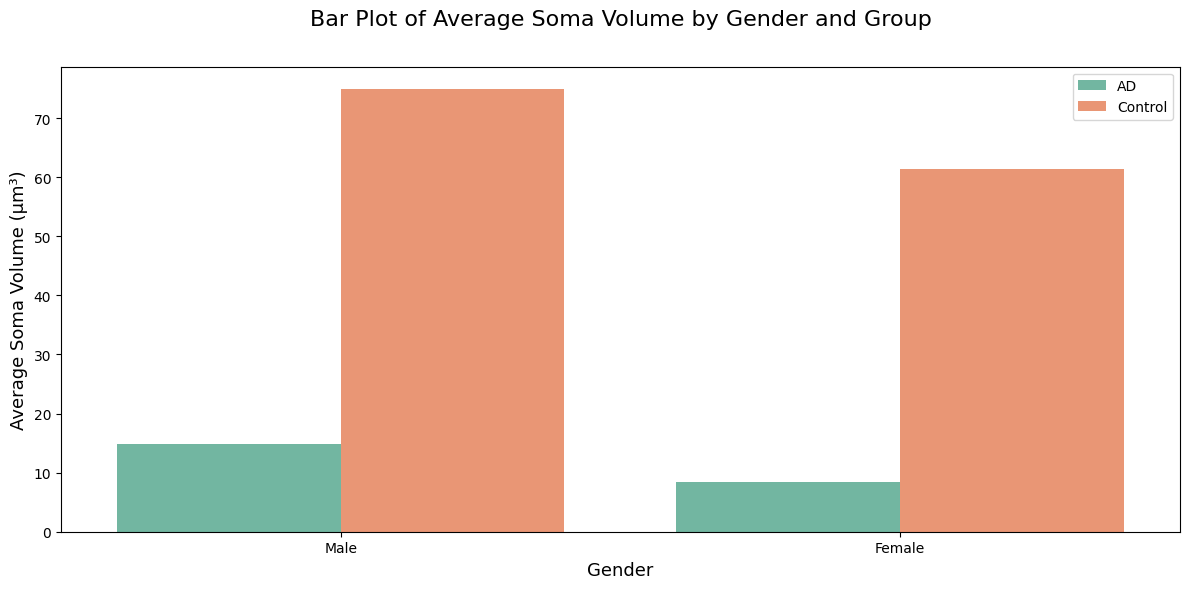

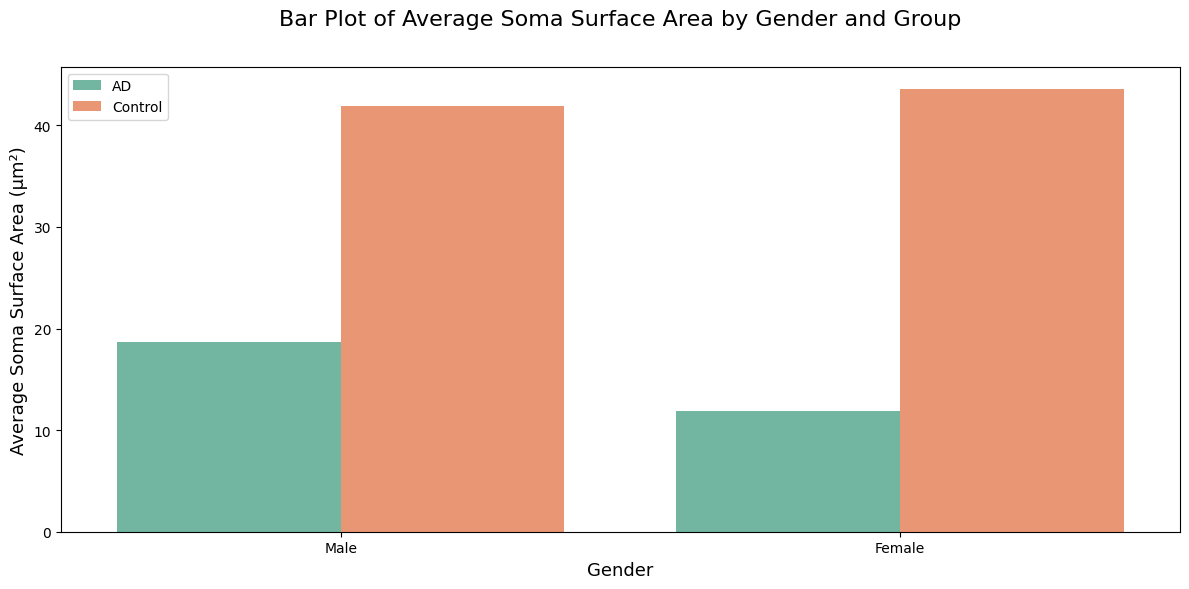

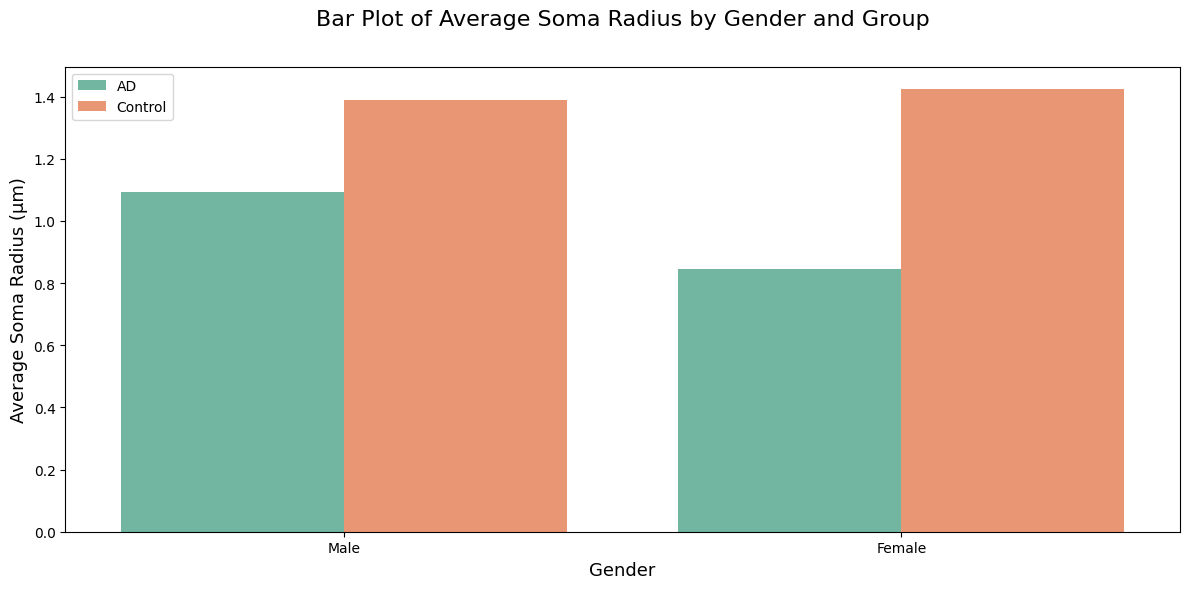

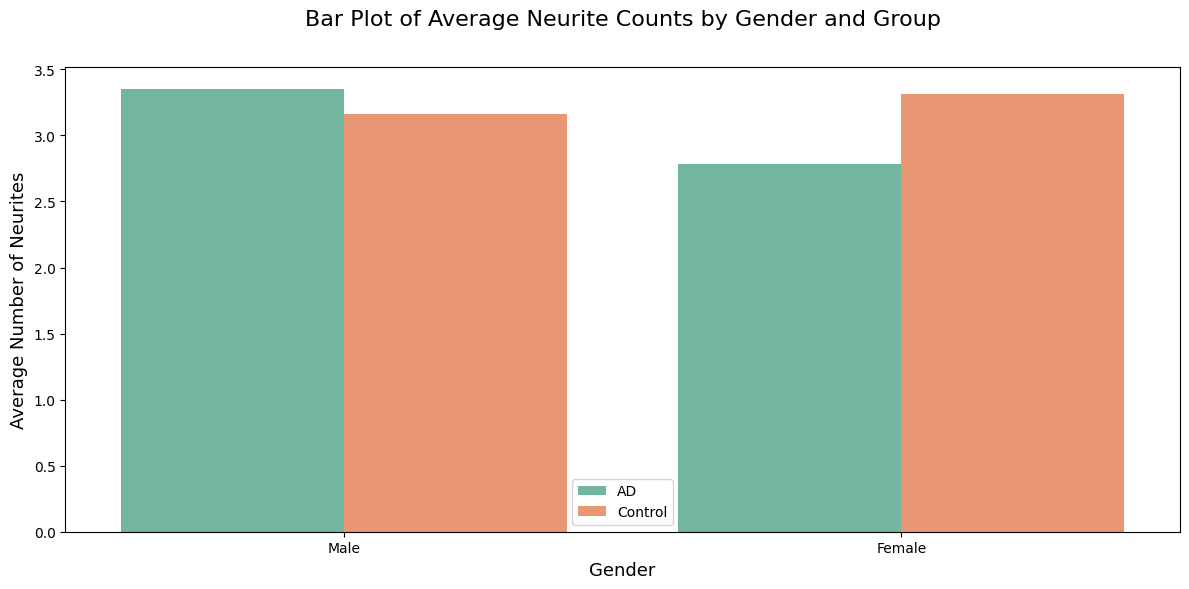

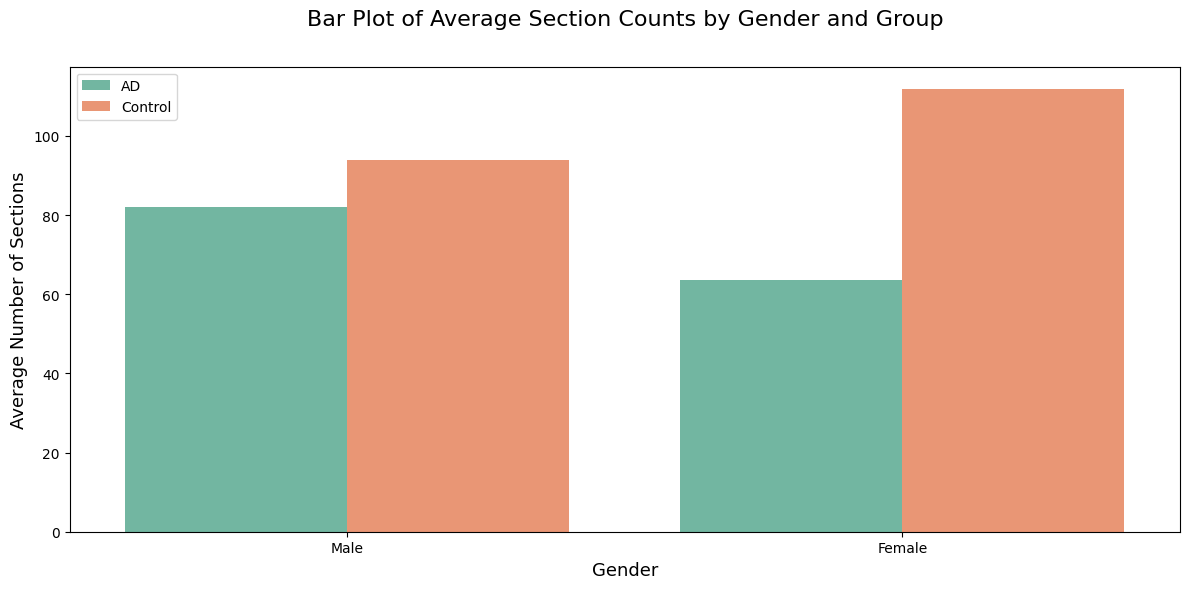

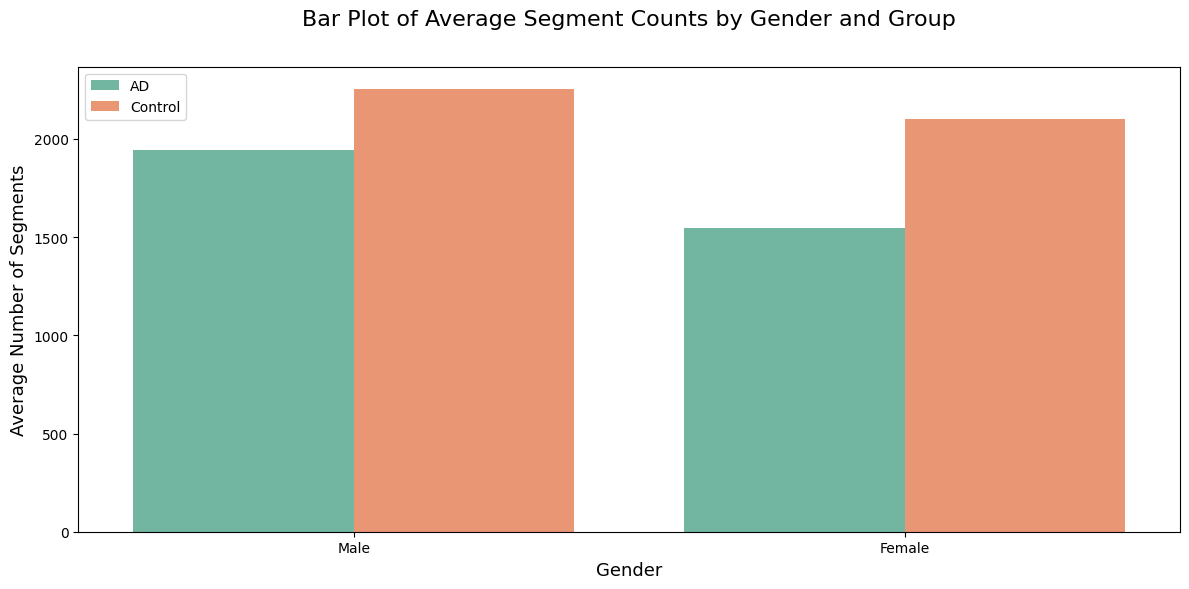

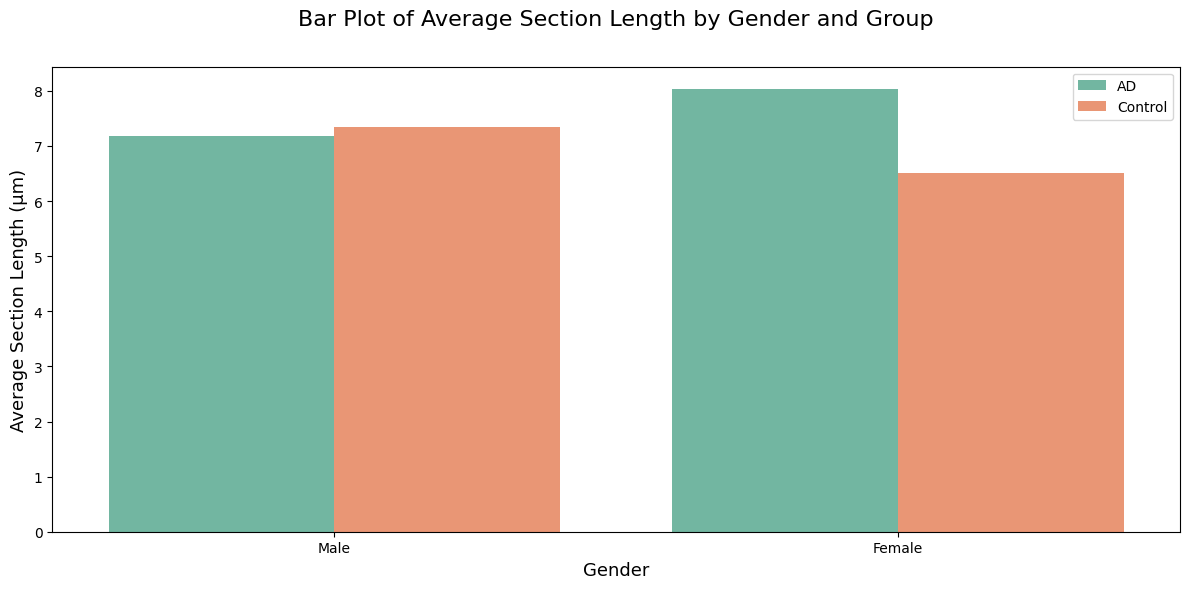

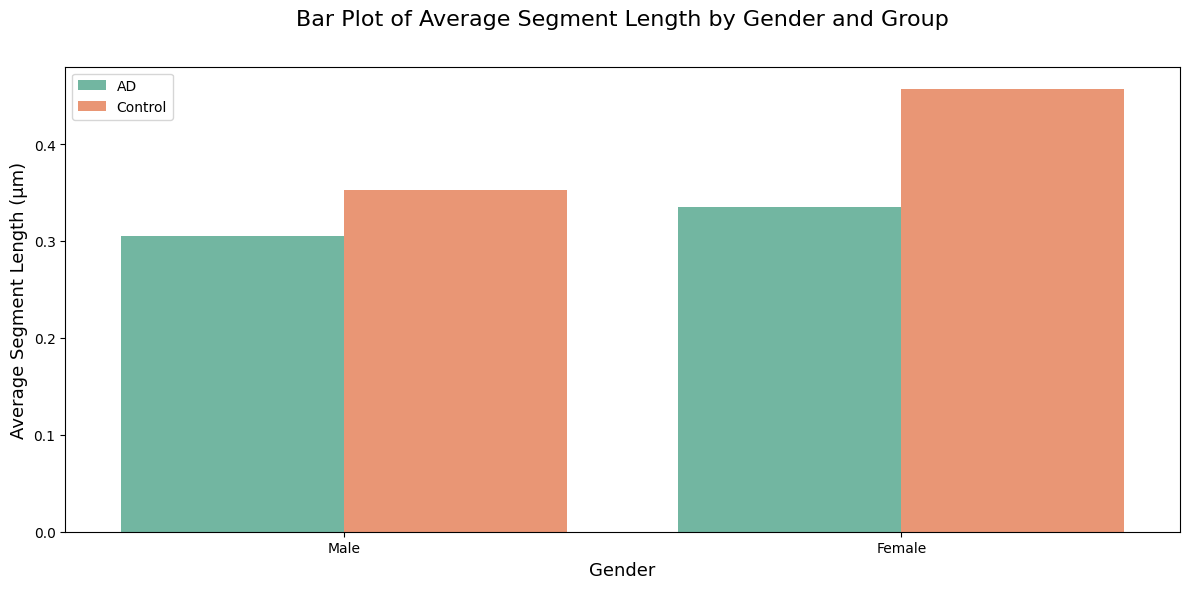

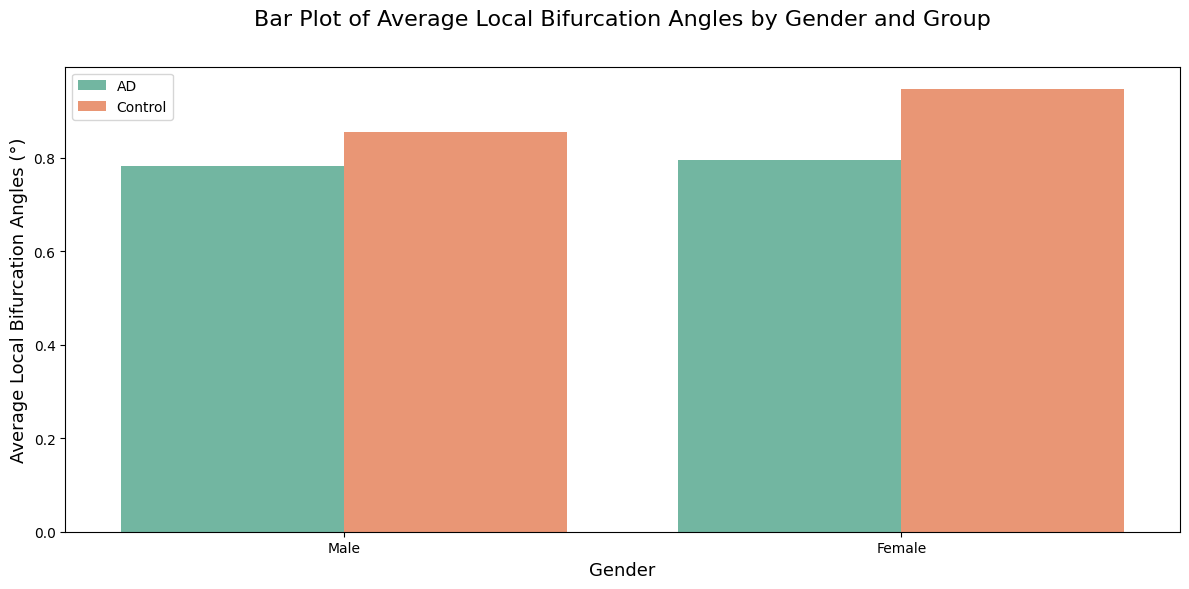

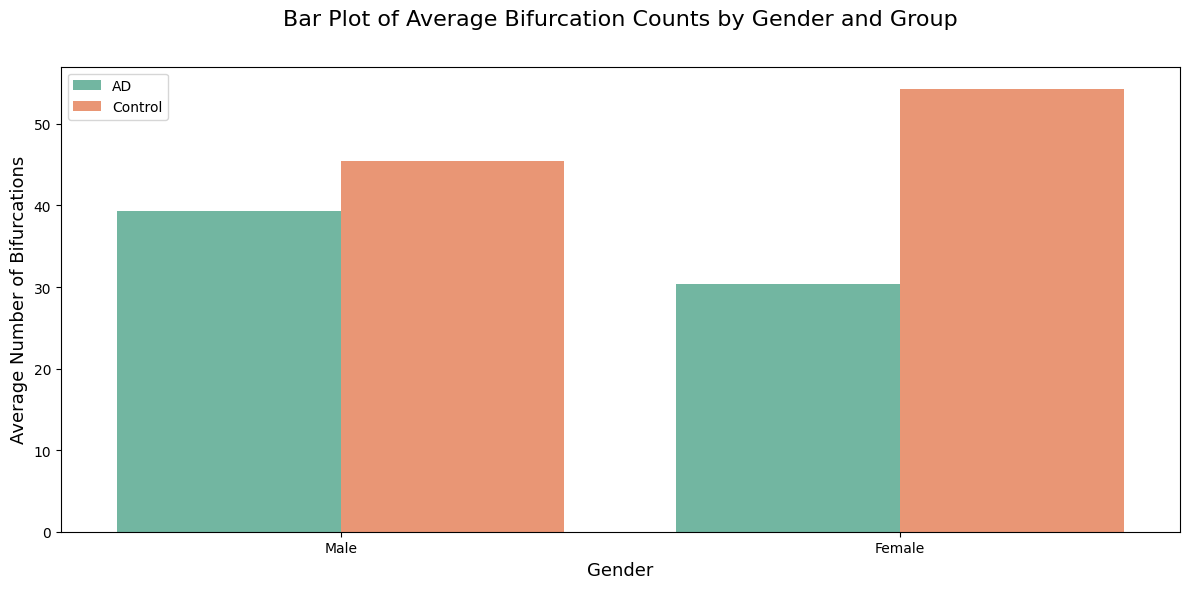

In [ ]:
for metric in metrics:
    plt.figure(figsize=(12, 6))

    avg_df = filtered_df.groupby(['gender', 'group'])[metric].mean().reset_index()

    sns.barplot(data=avg_df, x='gender', y=metric, hue='group', order=gender_order, palette='Set2')

    unit = metric_units.get(metric, 'Unit')

    if 'number_of_' in metric:
        metric_name = metric.replace("number_of_", "").replace("_", " ").title()
        singular_metric_name = make_singular(metric_name.split(" ")[-1])
        title = f'Bar Plot of Average {singular_metric_name} Counts by Gender and Group'
        y_label = f'Average Number of {metric_name}'

    elif metric == 'n_bifs':
        title = f'Bar Plot of Average Bifurcation Counts by Gender and Group'
        y_label = f'Average Number of Bifurcations'

    elif metric in ['mean_segment_length', 'mean_section_length']:
        metric_clean = metric.replace("mean_", "").replace("_", " ").title()
        title = f'Bar Plot of Average {metric_clean} by Gender and Group'
        y_label = f'Average {metric_clean}'
        if unit:
            y_label += f' ({unit})'
    elif metric == 'mean_local_bif_angle':
        title = f'Bar Plot of Average Local Bifurcation Angles by Gender and Group'
        y_label = f'Average Local Bifurcation Angles ({unit})'
    else:
        title = f'Bar Plot of Average {metric.replace("_", " ").title()} by Gender and Group'
        if unit is None:
            y_label = f'Average {metric.replace("_", " ").title()}'
        else:
            y_label = f'Average {metric.replace("_", " ").title()} ({unit})'

    plt.title(title, fontsize=16, pad=30)
    plt.xlabel('Gender', fontsize=13)
    plt.ylabel(y_label, fontsize=13)
    plt.legend(fontsize=10, title_fontsize=12)
    plt.tight_layout()

    plt.show()

In [ ]:
results_gender = []

for gender in ['Male', 'Female']:
    gender_df = filtered_df[filtered_df['gender'] == gender]

    for metric in metrics:
        vals_ad = gender_df[gender_df['group'] == 'AD'][metric].dropna()
        vals_control = gender_df[gender_df['group'] == 'Control'][metric].dropna()

        if len(vals_ad) >= 2 and len(vals_control) >= 2:
            t_stat, p_val = ttest_ind(vals_ad, vals_control, equal_var=False)
            results_gender.append({
                'gender': gender,
                'metric': metric,
                't_stat': t_stat,
                'p_val': p_val,
                'n_ad': len(vals_ad),
                'mean_ad': vals_ad.mean(),
                'std_ad': vals_ad.std(),
                'median_ad': vals_ad.median(),
                'n_control': len(vals_control),
                'mean_control': vals_control.mean(),
                'std_control': vals_control.std(),
                'median_control': vals_control.median()
            })

results_gender_df = pd.DataFrame(results_gender)
results_gender_df = results_gender_df.sort_values('p_val')
print(results_gender_df.head(20))

    gender                metric     t_stat          p_val  n_ad      mean_ad  \
14  Female    number_of_sections -23.696177  9.530905e-109   656    63.634146   
19  Female                n_bifs -23.536189  1.390158e-107   656    30.423780   
10  Female           soma_volume -20.952997   1.182493e-90   656     8.493276   
11  Female     soma_surface_area -20.440386   4.527637e-87   656    11.848793   
18  Female  mean_local_bif_angle -19.733311   2.315027e-81   656     0.794182   
16  Female   mean_section_length  20.307607   1.587991e-80   656     8.036971   
12  Female           soma_radius -18.918067   4.849914e-75   656     0.846386   
17  Female   mean_segment_length -16.809043   2.071566e-60   656     0.334773   
1     Male     soma_surface_area -10.837832   1.026923e-26   516    18.699284   
15  Female    number_of_segments -10.750103   5.099083e-26   656  1548.864329   
8     Male  mean_local_bif_angle -10.200068   7.011852e-24   516     0.781722   
0     Male           soma_vo

In [ ]:
# Multiply by 20 and ensure no value exceeds 1.0
results_gender_df['p_val'] = (results_gender_df['p_val'] * 20).clip(upper=1.0)

In [ ]:
results_gender_df['metric_clean'] = results_gender_df['metric'].apply(clean_metric_name)

In [ ]:
results_gender_df.to_csv('gender_ttest_results.csv', index=False)

In [ ]:
results_gender_df.head(5)

,gender,metric,t_stat,p_val,n_ad,mean_ad,std_ad,median_ad,n_control,mean_control,std_control,median_control,metric_clean
14,Female,number_of_sections,-23.696177,1.906181e-107,656,63.634146,38.439646,55.000000,2440,111.906148,68.041878,96.000000,Number of Sections
19,Female,n_bifs,-23.536189,2.780315e-106,656,30.423780,19.080152,26.000000,2440,54.297131,34.004580,46.000000,Number of Bifurcations
10,Female,soma_volume,-20.952997,2.364985e-89,656,8.493276,17.925472,1.581635,2440,61.341784,119.697053,8.548155,Soma Volume
11,Female,soma_surface_area,-20.440386,9.055274e-86,656,11.848793,15.129914,5.009803,2440,43.590632,70.940773,16.955226,Soma Surface Area
18,Female,mean_local_bif_angle,-19.733311,4.630055e-80,656,0.794182,0.114235,0.787121,2440,0.947472,0.314164,0.826658,Mean Local Bifurcation Angles


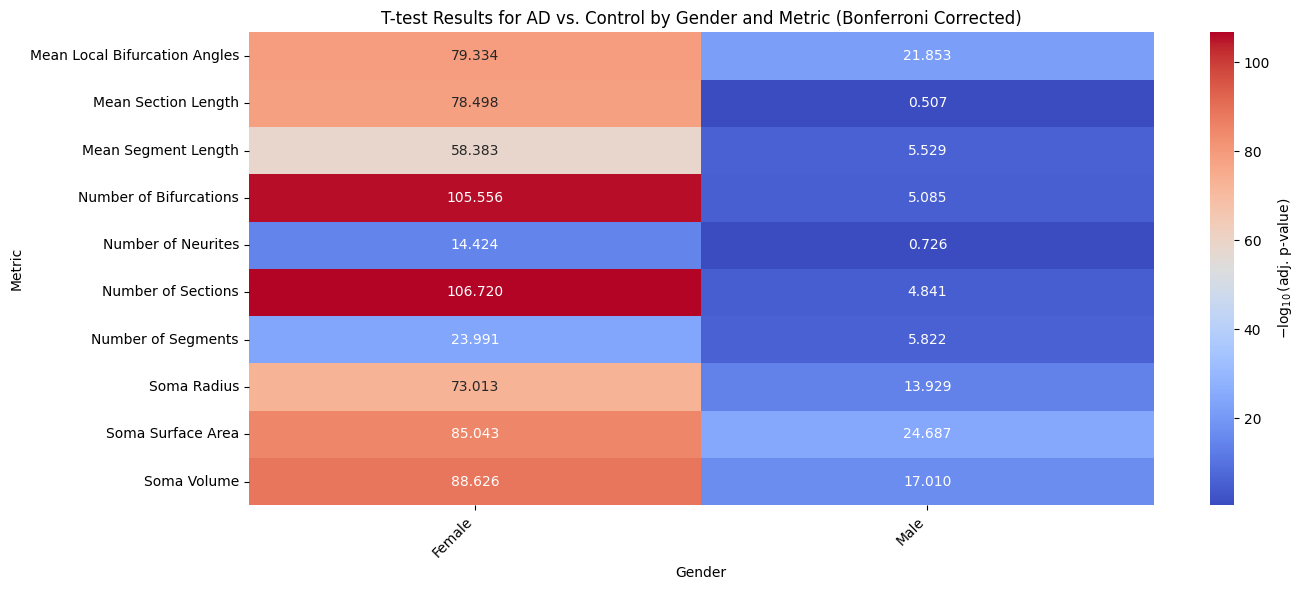

In [ ]:
# 1. Pivot and Transform
pval_matrix = results_gender_df.pivot(index='metric_clean', columns='gender', values='p_val')
log_pvals = -np.log10(pval_matrix.replace(0, 1e-300))

# 2. Plotting
plt.figure(figsize=(14, 6))

sns.heatmap(log_pvals,
            annot=True,
            fmt=".3f",
            cmap="coolwarm",
            cbar_kws={'label': r'$-\log_{10}(\text{adj. p-value})$'})

plt.title("T-test Results for AD vs. Control by Gender and Metric (Bonferroni Corrected)")
plt.xlabel("Gender")
plt.ylabel("Metric")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

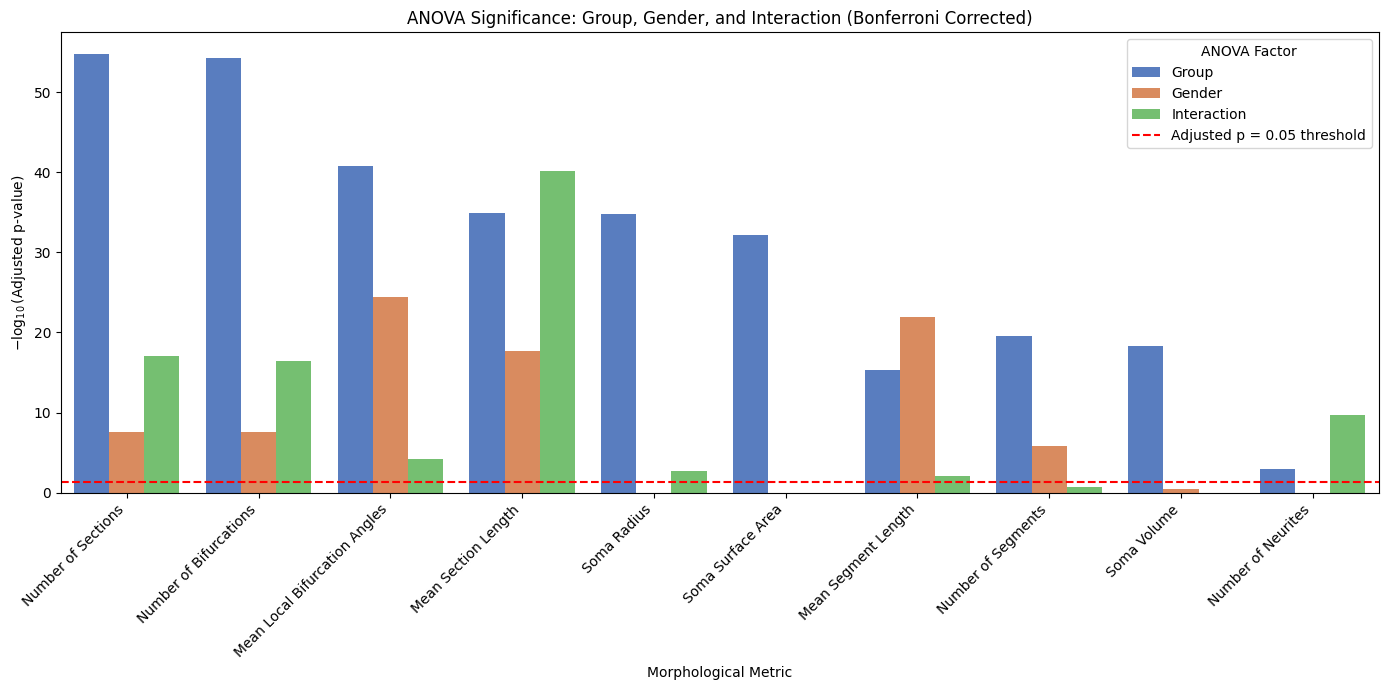

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Run ANOVA and extract raw p-values
anova_results_interaction = []

# Ensure you use the filtered_df (which should now be your Adult-Only cohort)
for metric in metrics:
    # Drop NAs for the specific columns to prevent model errors
    df_temp = filtered_df[['group', 'gender', metric]].dropna()

    # Check for sufficient group representation
    if len(df_temp['group'].unique()) >= 2 and \
       len(df_temp['gender'].unique()) >= 2:

        # FIX: Use Q() to properly quote the metric name for the Patsy formula
        # This prevents the "Number of rows mismatch" error
        formula = f'Q("{metric}") ~ C(group) * C(gender)'

        try:
            model = ols(formula, data=df_temp).fit()
            anova_table = sm.stats.anova_lm(model, typ=2)

            anova_results_interaction.append({
                'metric': metric,
                'sum_sq_group': anova_table.loc['C(group)', 'sum_sq'],
                'F_group': anova_table.loc['C(group)', 'F'],
                'p_group_raw': anova_table.loc['C(group)', 'PR(>F)'],

                'sum_sq_gender': anova_table.loc['C(gender)', 'sum_sq'],
                'F_gender': anova_table.loc['C(gender)', 'F'],
                'p_gender_raw': anova_table.loc['C(gender)', 'PR(>F)'],

                'sum_sq_interaction': anova_table.loc['C(group):C(gender)', 'sum_sq'],
                'F_interaction': anova_table.loc['C(group):C(gender)', 'F'],
                'p_interaction_raw': anova_table.loc['C(group):C(gender)', 'PR(>F)']
            })
        except Exception as e:
            print(f"Skipping {metric} due to error: {e}")

# 2. Convert to DataFrame
anova_interaction_df = pd.DataFrame(anova_results_interaction)

# 3. APPLY BONFERRONI CORRECTION (Factor of 20)
correction_factor = 20
for col in ['p_group', 'p_gender', 'p_interaction']:
    raw_col = col + '_raw'
    anova_interaction_df[col] = (anova_interaction_df[raw_col] * correction_factor).clip(upper=1.0)

# Sort and Save
anova_interaction_df = anova_interaction_df.sort_values('p_interaction')
anova_interaction_df.to_csv('anova_interaction_results_corrected.csv', index=False)

# 4. Prepare data for plotting
melted_df = pd.melt(
    anova_interaction_df,
    id_vars=['metric'],
    value_vars=['p_group', 'p_gender', 'p_interaction'],
    var_name='factor',
    value_name='p_corrected'
)

melted_df['factor'] = melted_df['factor'].replace({
    'p_group': 'Group',
    'p_gender': 'Gender',
    'p_interaction': 'Interaction'
})

melted_df['-log10(p_adj)'] = -np.log10(melted_df['p_corrected'].replace(0, 1e-300))
melted_df['metric_clean'] = melted_df['metric'].apply(clean_metric_name)

# 5. Handle plot ordering
metric_order = (anova_interaction_df
                .set_index('metric')[['p_group', 'p_gender', 'p_interaction']]
                .min(axis=1)
                .sort_values()
                .index.tolist())

metric_order_clean = [clean_metric_name(m) for m in metric_order]
melted_df['metric_clean'] = pd.Categorical(melted_df['metric_clean'],
                                           categories=metric_order_clean,
                                           ordered=True)

# 6. Final Visualization
plt.figure(figsize=(14, 7))
sns.barplot(data=melted_df, x='metric_clean', y='-log10(p_adj)', hue='factor', palette='muted')

plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='Adjusted p = 0.05 threshold')
plt.ylabel(r'$-\log_{10}(\text{Adjusted p-value})$')
plt.xlabel('Morphological Metric')
plt.title('ANOVA Significance: Group, Gender, and Interaction (Bonferroni Corrected)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='ANOVA Factor', loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd

def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.std(x, ddof=1) ** 2 + (ny - 1) * np.std(y, ddof=1) ** 2) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

summary_table = []

for metric in metrics:
    for sex in ['Male', 'Female']:
        control_vals = merged_df_no_outliers[(merged_df_no_outliers['group']=='Control') &
                                             (merged_df_no_outliers['gender']==sex)][metric].dropna()
        ad_vals = merged_df_no_outliers[(merged_df_no_outliers['group']=='AD') &
                                        (merged_df_no_outliers['gender']==sex)][metric].dropna()
        if len(control_vals) > 0 and len(ad_vals) > 0:
            t_stat, p_val = ttest_ind(ad_vals, control_vals, equal_var=False)
            pct_change = (ad_vals.mean() - control_vals.mean()) / control_vals.mean() * 100
            d = cohen_d(ad_vals, control_vals)
            summary_table.append({
                'Metric': metric,
                'Sex': sex,
                'Control Mean ± SD': f"{control_vals.mean():.2f} ± {control_vals.std():.2f}",
                'AD Mean ± SD': f"{ad_vals.mean():.2f} ± {ad_vals.std():.2f}",
                '% Change from Control': f"{pct_change:.2f}%",
                't-stat': t_stat,
                'p-value': p_val,
                "Cohen's d": d
            })

summary_df = pd.DataFrame(summary_table)
summary_df

,Metric,Sex,Control Mean ± SD,AD Mean ± SD,% Change from Control,t-stat,p-value,Cohen's d
0,soma_volume,Male,74.95 ± 283.61,14.85 ± 20.12,-80.19%,-9.009822,4.889211e-19,-0.239594
1,soma_volume,Female,61.34 ± 119.70,8.49 ± 17.93,-86.15%,-20.952997,1.182493e-90,-0.495792
2,soma_surface_area,Male,41.86 ± 85.49,18.70 ± 17.55,-55.33%,-10.837832,1.026923e-26,-0.304793
3,soma_surface_area,Female,43.59 ± 70.94,11.85 ± 15.13,-72.82%,-20.440386,4.527637e-87,-0.500903
4,soma_radius,Male,1.39 ± 1.18,1.09 ± 0.54,-21.43%,-8.164014,5.891969e-16,-0.276978
5,soma_radius,Female,1.43 ± 1.20,0.85 ± 0.48,-40.61%,-18.918067,4.849914e-75,-0.532173
6,number_of_neurites,Male,3.16 ± 1.54,3.35 ± 1.48,6.12%,2.602833,9.405539e-03,0.126457
7,number_of_neurites,Female,3.31 ± 1.69,2.79 ± 1.35,-15.86%,-8.343191,1.882448e-16,-0.323783
8,number_of_sections,Male,93.94 ± 62.17,82.04 ± 43.12,-12.67%,-4.982398,7.218037e-07,-0.203283
9,number_of_sections,Female,111.91 ± 68.04,63.63 ± 38.44,-43.14%,-23.696177,9.530905e-109,-0.766860


In [ ]:
summary_df.to_csv('baseline_results_table_morpho', index=False)

In [ ]:
from scipy.stats import ttest_ind

# 1. Overall Age Check
age_ad = filtered_df[filtered_df['group'] == 'AD']['age'].dropna()
age_control = filtered_df[filtered_df['group'] == 'Control']['age'].dropna()

t_stat, p_val = ttest_ind(age_ad, age_control, equal_var=False)

print("--- Overall Age Imbalance Check ---")
print(f"AD Mean Age:      {age_ad.mean():.2f} (n={len(age_ad)})")
print(f"Control Mean Age: {age_control.mean():.2f} (n={len(age_control)})")
print(f"T-test p-value:   {p_val:.4f}")

if p_val < 0.05:
    print("WARNING: Groups are NOT age-matched. Age is a significant confounder.")
else:
    print("SUCCESS: No significant age difference detected between groups.")

print("\n--- Age Check by Gender ---")
for gender in ['Male', 'Female']:
    g_df = filtered_df[filtered_df['gender'] == gender]
    age_ad_g = g_df[g_df['group'] == 'AD']['age'].dropna()
    age_control_g = g_df[g_df['group'] == 'Control']['age'].dropna()

    _, p_g = ttest_ind(age_ad_g, age_control_g, equal_var=False)
    print(f"{gender}: p={p_g:.4f} (AD: {age_ad_g.mean():.1f} vs Control: {age_control_g.mean():.1f})")

KeyError: 'age'